# Prueba de data x hora

In [33]:
# Ejecutar con revenIA
# version yf = 0.2.65

In [34]:
print('Conexion con mt5 en C:-Users-mvaldiviad-OneDrive - Falabella-Escritorio-Proyectos Personales-RevenIA-TradBot-mt5.ipynb')

Conexion con mt5 en C:-Users-mvaldiviad-OneDrive - Falabella-Escritorio-Proyectos Personales-RevenIA-TradBot-mt5.ipynb


In [ ]:
sys.exit("Entre 'df_oc_all base inicial' y 'df_oc_all base final', hay status que pasan de Abierta a Activa...eso no puede ocurrir [ver id 11]")

In [35]:
import yfinance as yf
import pandas as pd
import numpy as np
import os
import itertools
import tqdm
import random
import warnings
import sys
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

import mplfinance as mpf

In [36]:
opcion = 1 # 0 solo actualiza valores y 1 solo ejecuta el algorítmo

In [37]:
actualizar_valores = False
ejecutar_proceso = True

In [38]:
if opcion == 0:
    actualizar_valores = True
    ejecutar_proceso = False
elif opcion == 1:
    actualizar_valores = False
    ejecutar_proceso = True

In [39]:
carpeta_data = "../Data/"

In [40]:
#  dame el date en formato str YYYY-MM-DD para 30 días atrás desde hoy
date_inicial = (pd.Timestamp.now() - pd.DateOffset(days = 30)).strftime('%Y-%m-%d')
date_inicial

'2025-11-02'

In [41]:
import MetaTrader5 as mt5
import pandas as pd

# Inicializar MT5
mt5.initialize()

# Initialize MT5 connection
if not mt5.initialize():
    print("initialize() failed, error code =", mt5.last_error())
    quit()

In [42]:
# Prueba

valores = ['BTCUSD', 'ETHUSD', 'TSLA', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'NFLX']
for valor in valores:
    if not actualizar_valores:
        break
    
    # Nombre del símbolo (depende de tu broker, a veces es BTCUSD, BTCUSD.m, etc.)
    symbol = valor
    print('SY', symbol)

    # Seleccionar símbolo
    mt5.symbol_select(symbol, True)

    # Descargar datos: 100 velas de 1 hora (TIMEFRAME_H1)
    rates = mt5.copy_rates_from_pos(symbol, mt5.TIMEFRAME_H1, 0, 1000) # Max 60000

    #print(rates)
    # Convertir a DataFrame para trabajar cómodo
    df = pd.DataFrame(rates)

    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.columns = ['DateTime', 'Open', 'High', 'Low', 'Close', 'Tick_Volume', 'Spread', 'Real_Volume']

    display(df.tail())

    data_old = pd.DataFrame()
    if f'{valor}.csv' in os.listdir(carpeta_data):
        data_old = pd.read_csv(f'{carpeta_data}{valor}.csv')
        data_old['DateTime'] = pd.to_datetime(data_old['DateTime'])
    data = pd.concat([data_old, df]).drop_duplicates(subset=['DateTime']).reset_index(drop=True)
    data.to_csv(f'{carpeta_data}{valor}.csv', index=False)

In [43]:
"""
valores = ['BTC-USD', 'ETH-USD', 'TSLA', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'NFLX']
for valor in valores:
    if not actualizar_valores:
        break
    # Definir ticker y periodo
    data = yf.download(valor, start = date_inicial, interval = '60m')  # intervalo de 60 minutos
    data = data.reset_index()
    data.columns = ['DateTime', 'Close', 'High', 'Low', 'Open', 'Volume']
    data['DateTime'] = pd.to_datetime(data['DateTime'])

    display(valor, data)
    
    data_old = pd.DataFrame()
    if f'{valor}.csv' in os.listdir(carpeta_data):
        data_old = pd.read_csv(f'{carpeta_data}{valor}.csv')
        data_old['DateTime'] = pd.to_datetime(data_old['DateTime'])
    data = pd.concat([data_old, data]).drop_duplicates(subset=['DateTime']).reset_index(drop=True)
    data.to_csv(f'{carpeta_data}{valor}.csv', index=False)
"""


"\nvalores = ['BTC-USD', 'ETH-USD', 'TSLA', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'NFLX']\nfor valor in valores:\n    if not actualizar_valores:\n        break\n    # Definir ticker y periodo\n    data = yf.download(valor, start = date_inicial, interval = '60m')  # intervalo de 60 minutos\n    data = data.reset_index()\n    data.columns = ['DateTime', 'Close', 'High', 'Low', 'Open', 'Volume']\n    data['DateTime'] = pd.to_datetime(data['DateTime'])\n\n    display(valor, data)\n\n    data_old = pd.DataFrame()\n    if f'{valor}.csv' in os.listdir(carpeta_data):\n        data_old = pd.read_csv(f'{carpeta_data}{valor}.csv')\n        data_old['DateTime'] = pd.to_datetime(data_old['DateTime'])\n    data = pd.concat([data_old, data]).drop_duplicates(subset=['DateTime']).reset_index(drop=True)\n    data.to_csv(f'{carpeta_data}{valor}.csv', index=False)\n"

# Funciones

In [44]:
if not ejecutar_proceso:
    sys.exit()

In [45]:

def calcular_distancias(df, find_low=True, find_high=True):
    n = len(df)
    df = df.copy()
    
    if find_low:
        df["Low_left"] = np.nan
        df["Low_right"] = np.nan
    if find_high:
        df["High_left"] = np.nan
        df["High_right"] = np.nan

    max_t = df["t"].max()

    for i in range(n):
        low_val = df.loc[i, "Low"]
        high_val = df.loc[i, "High"]
        t_i = df.loc[i, "t"]
        
        if find_low:
            # Buscar hacia la izquierda (Low)
            for j in range(i-1, -1, -1):
                if df.loc[j, "Low"] <= low_val <= df.loc[j, "High"]:
                    df.loc[i, "Low_left"] = t_i - df.loc[j, "t"]
                    break

            # Buscar hacia la derecha (Low)
            for j in range(i+1, n):
                if df.loc[j, "Low"] <= low_val <= df.loc[j, "High"]:
                    df.loc[i, "Low_right"] = df.loc[j, "t"] - t_i
                    break

        if find_high:
            # Buscar hacia la izquierda (High)
            for j in range(i-1, -1, -1):
                if df.loc[j, "Low"] <= high_val <= df.loc[j, "High"]:
                    df.loc[i, "High_left"] = t_i - df.loc[j, "t"]
                    break

            # Buscar hacia la derecha (High)
            for j in range(i+1, n):
                if df.loc[j, "Low"] <= high_val <= df.loc[j, "High"]:
                    df.loc[i, "High_right"] = df.loc[j, "t"] - t_i
                    break

    # Rellenar los NaN con t o max(t) - t
    if find_low:
        df["Low_left"] = df["Low_left"].fillna(df["t"])
        df["Low_right"] = df["Low_right"].fillna(max_t - df["t"])
    if find_high:
        df["High_left"] = df["High_left"].fillna(df["t"])
        df["High_right"] = df["High_right"].fillna(max_t - df["t"])

    return df


In [46]:
def graficar_df_extremos(df_extremos, graficar = False):
    
    if not graficar:
        return None
    # Grafica en una matriz de 2x1, Low e y
    """
    plt.figure(figsize=(21, 10))
    #plt.subplot(1, 1, 1)
    plt.plot(df_extremos['DateTime'], df_extremos['Low'], linestyle='-', color='b', label='Low')
    plt.plot(df_extremos['DateTime'], df_extremos['High'], linestyle='-', color='g', label='High')
    plt.xlabel('DateTime')
    plt.ylabel('Low')
    plt.title('Gráfico de Low en función de DateTime')
    plt.grid()
    plt.legend()
    plt.show()
    """
    print('TO DO: Poner los parámetros asociados en cada curva, ej y = izq + lambda * der....w = t ** n...')
    plt.figure(figsize=(21, 10))
    plt.subplot(2, 2, 1)
    plt.plot(df_extremos['DateTime'], df_extremos['y'], linestyle='-', color='r')
    plt.xlabel('DateTime')
    plt.ylabel('y (a mayor y, mayor distancia izq y derecha con otras velas)')
    plt.title('Gráfico de y en función de DateTime')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.subplot(2, 2, 2)
    plt.plot(df_extremos['DateTime'], df_extremos['w'], linestyle='-', color='m')
    plt.xlabel('DateTime')
    plt.ylabel('w (distancia ponderada)')
    plt.title('w (a mayor w, más reciente es la vela)')
    plt.grid()
    plt.legend()
    plt.subplot(2, 2, 3)
    plt.plot(df_extremos['DateTime'], df_extremos['h_dist'], linestyle='-', color='c')
    plt.xlabel('DateTime')
    plt.ylabel('x (distancia ponderada)')
    plt.title('h_dist (mayor h_dist implica más cercanía con el soporte seleccionado más cercano)')
    plt.grid()
    plt.subplot(2, 2, 4)
    plt.plot(df_extremos['DateTime'], df_extremos['z'], linestyle='-', color='black')
    plt.xlabel('DateTime')
    plt.ylabel('z (distancia ponderada)')
    plt.title('z (w * h_dist * y)')
    plt.grid()
    plt.legend()
    plt.show()

    return None

In [47]:
# Al Low en df extremos, asignarle el soporte más cercano en conjunto_N
def asignar_soporte(df, soportes):
    df = df.copy()
    df['Soporte'] = df['Low'].apply(lambda x: min(soportes, key=lambda s: abs(s - x)))
    return df

def calcular_FO(df_extremos, conjunto_N, lambda_ponderador):

    biobjetivo = True
    
    df_extremos = asignar_soporte(df_extremos, conjunto_N)
    df_extremos['dist'] = abs(df_extremos['Low'] - df_extremos['Soporte']) ** 2
    dist_max = df_extremos['dist'].max()
    df_extremos['h_dist'] = 1 - df_extremos['dist'] / dist_max
    df_extremos
    
    # Calcular la función objetivo

    df_extremos['z'] = df_extremos['y'] * df_extremos['w'] * df_extremos['h_dist']
    # z debe ser grande
    # y: mejor representación de soporte
    # w: mas cercano
    # h_dist: mejor ajuste al soporte del conjunto n

    L_n = list(conjunto_N)
    L_n.sort()
    H_n = [L_n[i] - L_n[i-1] for i in range(1, len(L_n))]

    # calcula promedio de conjunto_N
    promedio_conjunto_H = np.mean(H_n)
    # desviación estándar de conjunto_N
    desviacion_conjunto_H = np.std(H_n)

    # cv del conjunto n
    cv_conjunto_H = desviacion_conjunto_H / promedio_conjunto_H

    # cv_conjunto_N debe ser pequeño
    
    if biobjetivo:
        #print("df_extremos['z'].sum() / len(df_extremos)", df_extremos['z'].sum() / len(df_extremos), df_extremos['z'].sum(), len(df_extremos))
        #print('cv_conjunto_H', cv_conjunto_H, desviacion_conjunto_H, promedio_conjunto_H)
        # FO = sum(z) - lambda * cv_conjunto_N
        #sys.exit('También normalizar cv conjunto H y definir un nuevo lambda_ponderador inicial')
        FO = df_extremos['z'].sum() / len(df_extremos) - lambda_ponderador * cv_conjunto_H # Se divide por len para normalizar
    else:
        FO = (df_extremos['z'].sum() / len(df_extremos)) / cv_conjunto_H
        
    FO = float(FO)
    return FO, df_extremos

In [48]:
def traspasos_entre_conjuntos(conjunto_M, conjunto_N, sizes):
    if sizes == []:
        return conjunto_M, conjunto_N
    if sizes[0] + sizes[1] != len(conjunto_M) + len(conjunto_N):
        sys.exit('Error en sizes declarados')
    elif (sizes[0] != len(conjunto_M)) or (sizes[1] != len(conjunto_N)):
        delta = len(conjunto_M) - sizes[0]
        if delta > 0:
            #pasar delta elementos random de conjunto_M a conjunto_N
            elementos_a_pasar = random.sample(list(conjunto_M), delta)
            for elem in elementos_a_pasar:
                conjunto_M.remove(elem)
                conjunto_N.add(elem)
        else:
            #pasar delta elementos random de conjunto_N a conjunto_M
            elementos_a_pasar = random.sample(list(conjunto_N), -delta)
            for elem in elementos_a_pasar:
                conjunto_N.remove(elem)
                conjunto_M.add(elem)
    return conjunto_M, conjunto_N

In [49]:
def buscar_soportes_optimos(df_extremos, conjunto_N, conjunto_M, lambda_ponderador, sizes = []):
    
    conjunto_M, conjunto_N = traspasos_entre_conjuntos(conjunto_M, conjunto_N, sizes)
    
    # Uno a uno, reemplaza un punto del conjunto N por uno del conjunto M
    print('Evaluar cortar despues de un tiempo o si la FO no mejora más que alpha %')    
    df_FO = pd.DataFrame(columns = ['Iteracion', 'FO'])

    # inicialización
    FO, df_extremos = calcular_FO(df_extremos, conjunto_N, lambda_ponderador)
    i = 0
    while True:
        cambios = False
        #print('i', i)
        j = 0
        for n, m in itertools.product(conjunto_N, conjunto_M):
            j += 1
            #print(n, m)
            
            conjunto_N_iter = conjunto_N.copy()
            conjunto_N_iter.remove(n)
            conjunto_N_iter.add(m)
            
            conjunto_M_iter = conjunto_M.copy()
            conjunto_M_iter.remove(m)
            conjunto_M_iter.add(n)

            FO_iter, df_extremos_iter = calcular_FO(df_extremos, conjunto_N_iter, lambda_ponderador)
            
            if FO_iter > FO:
                #print(f'Nueva FO: {round(FO_iter, 1)} > {round(FO, 1)}, con n={round(n, 0)} por m={round(m, 0)}')
                #print(f'Mejora de {round(FO_iter - FO, 2)}')
                FO = FO_iter
                df_extremos = df_extremos_iter
                conjunto_N = conjunto_N_iter
                conjunto_M = conjunto_M_iter
                cambios = True
                break
                
        df_FO_new = pd.DataFrame({'Iteracion': [i], 'FO': [FO], 'n_iters': [j]})
        df_FO = pd.concat([df_FO, df_FO_new])
        i += 1
        if not cambios:
            break
    
    return conjunto_N, conjunto_M, df_extremos, df_FO


In [50]:
def graficar_performance_FO(df_FO, graficar = False):
    if not graficar:
        return None
    # Graficar df_FO a doble eje (FO y n_iters vs iteracion)

    plt.figure(figsize = (21, 7))
    plt.plot(df_FO['Iteracion'], df_FO['FO'], linestyle='-', color='b', label='FO')
    plt.ylabel('FO')
    plt.xlabel('Iteración')
    plt.twinx()
    plt.plot(df_FO['Iteracion'], df_FO['n_iters'], linestyle='-', color='r', label='n_iters')
    plt.ylabel('n_iters')
    plt.title('Evolución de la Función Objetivo (FO) y n_iters por Iteración')
    plt.grid()
    plt.show()
    return None

In [51]:
def graficar_soportes_all(df_0, conjunto_N, graficar = False, graficar_zoom = False):
        
    if graficar_zoom:
        df_0 = df_0.tail(100)
        minimo, maximo = df_0['Low'].min(), df_0['High'].max()
        plt.figure(figsize = (21, 7))
        plt.plot(df_0['DateTime'], df_0['Low'], linestyle='-', color='b', label='Low')
        plt.plot(df_0['DateTime'], df_0['High'], linestyle='-', color='g', label='High')
        for n in list(conjunto_N):
            if minimo <= n <= maximo:
                plt.axhline(y = n, color = 'r', linestyle = '--', alpha = 0.5)
        plt.xlabel('DateTime')
        plt.ylabel('Price')
        plt.title('Gráfico de Low en función de DateTime [Zoom]')
        plt.grid() # Agrega una cuadrícula
        plt.legend()
        plt.show()
        return None
    
    if not graficar:
        return None
        

    plt.figure(figsize = (21, 7))
    plt.plot(df_0['DateTime'], df_0['Low'], linestyle='-', color='b', label='Low')
    plt.plot(df_0['DateTime'], df_0['High'], linestyle='-', color='g', label='High')
    for n in list(conjunto_N):
        plt.axhline(y = n, color = 'r', linestyle = '--', alpha = 0.5)
    plt.xlabel('DateTime')
    plt.ylabel('Price')
    plt.title('Gráfico de Low en función de DateTime')
    plt.grid() # Agrega una cuadrícula
    plt.legend()
    plt.show()
    
    return None


In [52]:
def generar_nuevas_oc(df_oc_all, conjunto_N, limite_low, limite_high, beta_low, beta_up, ultimo_cierre, delta_cambio_SL, delta_trigger, ultimo_periodo, delta_SL_LP):
    df_oc = pd.DataFrame()
    id_ = df_oc_all.shape[0] + 1
    n_distinct = set() # Por defecto vacío
    
    display('df_oc_all base inicial', df_oc_all)
    
    if ('Status' in df_oc_all.columns) and ('Monto Compra (lotes)' in df_oc_all.columns):
        df_rev = df_oc_all[(df_oc_all['Status'] == 'Activa') & (df_oc_all['Monto Compra (lotes)'].notna())]
        if len(df_rev) > 0:
            display('df_rev', df_rev)
            sys.exit('No pueden haber activas con monto de compra notna')
    if len(df_oc_all) > 0:
        # Si están activas, se desactivan
        df_oc_all['Status'] = np.where(df_oc_all['Status'] == 'Activa', 'Recien Inactiva', df_oc_all['Status'])
    
        n_distinct = set(df_oc_all[df_oc_all['Status'] == 'Recien Inactiva']['n'])
        
    for n in list(conjunto_N):
        if n in n_distinct: # No se "reemplaza" un soporte que se mantiene
            # Volver a "Activar"
            df_oc_all.loc[df_oc_all['n'] == n, 'Status'] = 'Activa'
            continue
        #print(n)
        if n < limite_low:
            beta = beta_low
        if n > limite_high:
            beta = beta_up
        else: # interpolación
            beta = beta_low + (beta_up - beta_low) * (n - limite_low) / (limite_high - limite_low)
        
        # Definir si es superior o inferior
        if n <= ultimo_cierre:
            tipo_oc = 'I'  # Inferior
            cambio_SL = None
            trigger = n # Se ejecuta la orden de compra en n
        else:
            tipo_oc = 'S'  # Superior
            cambio_SL = n * (1 + delta_cambio_SL / 100)
            trigger = cambio_SL * (1 + delta_trigger / 100)
        
        
        df_oc_new = pd.DataFrame({'id': [id_],
                                'tipo_oc': [tipo_oc],
                                'n': [n],
                                'beta': [beta], # Proporcion de la cuenta a comprar
                                'cambio_SL': [cambio_SL],
                                'trigger': [trigger],
                                'SL_LP': [n - delta_SL_LP],
                                'Status': ['Activa'],
                                'Monto Compra (lotes)': [np.nan],
                                'Valor_actual': [0]}) # Activa (esperando gatillar), Inactiva (fue reemplazada), Abierta (actualmente abierta), 'Cerrada' (se cerró la orden)
        df_oc = pd.concat([df_oc, df_oc_new])
        id_ += 1
        #print('beta para n =', n, ' es ', beta)

    if len(df_oc) > 0:
        df_oc['ultimo_cierre'] = ultimo_cierre
        df_oc['periodo'] = ultimo_periodo
        
        #display(f'df_oc {len(conjunto_N)}', df_oc)
        df_oc = df_oc[['periodo', 'ultimo_cierre', 'id', 'tipo_oc', 'n', 'beta', 'cambio_SL', 'trigger', 'SL_LP', 'Status', 'Monto Compra (lotes)', 'Valor_actual']]
        df_oc_all = pd.concat([df_oc_all, df_oc]).reset_index(drop=True)
    df_oc_all['Status'] = np.where(df_oc_all['Status'] == 'Recien Inactiva', 'Inactiva', df_oc_all['Status'])
    
    display('df_oc_all base final', df_oc_all)
    return df_oc_all

In [53]:
def actualizar_stop_loss_ordenes_abiertas(df_oc_all, cambio_SL, valor):
    print('\n\n\n actualizar_stop_loss_ordenes_abiertas')
    display('df_oc_all', df_oc_all)
    
    print('cambio_SL', cambio_SL)
    sys.exit('Desarrollar, solo para operaciones abiertas y si cambio_SL es mayor al precio de compra')

In [54]:
def ejecutar_orden_de_compra(df_oc_all, cuenta_size, beta, trigger, sl_lp, valor, _id):
    if valor not in ['BTCUSD', 'ETHUSD']:
        sys.exit('Solo desarrollado para BTCUSD por ahora...cambiar lógica de grano lote y U')
        
    granos_lotes = {'BTCUSD': 0.01, 'ETHUSD': 0.1}
    unidades = {'BTCUSD': 1, 'ETHUSD': 1}
    grano_lote = granos_lotes[valor] # tamaño mínimo de lote para BTCUSD
    U = unidades[valor] # Unidades de lote: 1 lote = 1 BTCUSD

    monto_compra = (cuenta_size * (beta / 100) / ((trigger - sl_lp) * U)) // grano_lote * grano_lote
    monto_compra # Lotes

    # Entonces, se ajusta  el SL_LP 
    if monto_compra == 0:
        sl_lp_new = sl_lp
    else:
        sl_lp_new = trigger - cuenta_size * (beta / 100) / (monto_compra * U)

    # Validacion
    if abs(monto_compra - (cuenta_size * (beta / 100) / ((trigger - sl_lp_new) * U))) > 0.001:
        sys.exit('Error en cálculo de monto compra y SL_LP_new')

    # Se agregan / actualizan los campos

    df_oc_all.loc[df_oc_all['id'] == _id, 'Monto Compra (lotes)'] = monto_compra
    df_oc_all.loc[df_oc_all['id'] == _id, 'SL_LP'] = sl_lp_new
    df_oc_all.loc[df_oc_all['id'] == _id, 'Status'] = 'Abierta' 
    df_oc_all.loc[df_oc_all['id'] == _id, 'Valor_actual'] = 0 # Nada cuando se crea
    
    return df_oc_all

In [55]:
def obtener_df_extremos(df_0, k, n, N, M, existe_solucion = False, conjunto_N = set()):
    df_extremos = calcular_distancias(df_0, find_high = False) # Calcula las distancias a los mínimos anteriores y futuros
    
    # Poonderadores (audios wsp personal 251002)
    df_extremos['y'] = df_extremos['Low_left'] + k * df_extremos['Low_right']
    df_extremos['w'] = df_extremos['t'] ** n
    
    # BUSQUEDA DE SOPORTES OPTIMOS
    
    print('N-M', N, M)

    p_min, p_max = df_extremos['Low'].min(), df_extremos['Low'].max()
    print('p_min y p_max', p_min, p_max)
    
    if existe_solucion:
        # Se debe entregar conjunto_N y sizes
        conjunto_M = set(np.linspace(p_min, p_max, M + N - len(conjunto_N)).tolist()) # delta

    else:
        # Si no existe solución, generar todas las posibles
        all_soluciones_posibles = np.linspace(p_min, p_max, M + N).tolist()
        print('len all posibles soluciones (N+M) ', len(all_soluciones_posibles))
        conjunto_N = set(random.sample(all_soluciones_posibles, N)) # Elegir N random de este conjunto (deben ser distintas)
        conjunto_M = set(all_soluciones_posibles) - conjunto_N
            
    print('L(N) * L(M)', len(conjunto_N), len(conjunto_M), len(conjunto_N) * len(conjunto_M))
    
    return df_extremos, conjunto_N, conjunto_M



# Algorítmo

In [56]:
# Que viene después?

# 0. Agregar una nueva vela al df y hacer lo siguiente
# 1: Recalcular soportes y REEMPLAZAR los que estaban (esto puede hacerse cada x velas, no en todas) 
    # 1a. Crear ordenes de compra, bajo el precio inicial, en los soportes N (siempre)
    # 1b. Crear OC arriba del precio, siempre y cuando el precio máximo de la nueva vela, active el umbral
# 2: Evaluar si se ejecuta una OC abajo (toque de soporte) y/o una OC arriba (alcanza el trigger [gatillante]) > Ejecutarla y guardarla en una BD
#     Incluir en la BD el $ en cuenta, para calcular posteriormente pérdida o ganancia
# 3: Generar cambios de SL, si se gatilla una OC arriba
# 4: Evaluar si hay cierres de operación y cerrar en caso de que existan
# 5: Con RLM, y gradient descent (70% train - 30% test), optimizar los parámetros declarados arriba

# ** En todos los casos, ir guardando los registros

## Parámetros iniciales

In [57]:
valor = 'BTCUSD'
valor = 'ETHUSD'
paso = 24 * 14 # cada 14 días

In [58]:
display_0 = True # Muestra df head inicial y el gráfico de velas completo
display_1 = False #True # Gráfico de velas, cada vez que una vela se agrega
graficar_extremos = True
graficar_perf_FO = True
graficar_soportes = True

## Parámetros sensibilizados por grad descent

In [59]:
# Parámetros

# T: Cantidad de días previos para selección de la ventana
T = 60 # 60 días
# k: ponderador para mínimos de los días futuros: P = delta pasado + k * delta futuro
k = 1
# n: exp de ponderación por tiempo: Ponderación por tiempo: w_i = exp(-n*(T-i)), i = 1,...,T / o puede ser w_i = A * t^n 
n = 3
# M: Cantidad de "soportes tentativos" fuera de los ocupados
M = 50
# N: Cantidad de "soportes" ocupados
N = 20
# lambda: ponderador para FO: Calidad resistencias - lambda * desv(h) / prom(h) ...h es la separación entre resistencias h_i = r_i - r_(i-1), para todo i = 2,...,N
lambda_ponderador = 1 / 60000
# delta trigger (en %), sobre el cambio SL
delta_trigger = 1
# delta cambio stop loss (en %)
delta_cambio_SL = 1

# Que % (en %) máximo de la cuenta se arriesga a mu - 2 desv estandar (beta low) y a mu + 2 desv estandar (beta up)
beta_low = 4.5
beta_up = 4

# Cuantas desv estandar abajo debe estar el SL de largo plazo
z_sl_lp = 1

# Recordar que el orden, de arriba hacia abajo es delta trigger / delta cambio SL / soporte

In [60]:
print('Cambiar a estrategia con operaciones de minimo lotaje hasta llegar a aprox \n10k usd...sl de largo plazo debe ser el menor posible para comprar por ejemplo 0.01 BTCUSD')
sys.exit()

Cambiar a estrategia con operaciones de minimo lotaje hasta llegar a aprox 
10k usd...sl de largo plazo debe ser el menor posible para comprar por ejemplo 0.01 BTCUSD


SystemExit: 

In [61]:
sizes = (M, N)

## Ejecución

In [62]:
cuenta_size = 3000 # Inicial, en USD
activar = True # Activar! Desactivado mientras solo para pruebas

In [63]:
valor

'ETHUSD'

'All gráfico'

,DateTime,Open,High,Low,Close,Tick_Volume,Spread,Real_Volume
0,2021-10-27 16:00:00,3975.23,3997.24,3949.80,3978.40,6258,39,0
1,2021-10-27 17:00:00,3978.40,4005.37,3976.33,3995.36,4345,39,0
2,2021-10-28 09:00:00,4118.85,4161.64,4109.15,4161.54,2528,268,0
3,2021-10-28 10:00:00,4162.30,4175.11,4138.99,4148.59,3998,268,0
4,2021-10-28 11:00:00,4148.42,4157.73,4120.62,4153.45,3895,247,0
...,...,...,...,...,...,...,...,...
35885,2025-12-01 16:00:00,2745.75,2755.88,2718.63,2729.58,7016,98,0
35886,2025-12-01 17:00:00,2729.78,2752.12,2727.61,2739.21,4450,98,0
35887,2025-12-01 18:00:00,2739.41,2757.63,2723.96,2749.01,4342,98,0
35888,2025-12-01 19:00:00,2749.03,2753.18,2729.64,2740.14,4110,98,0


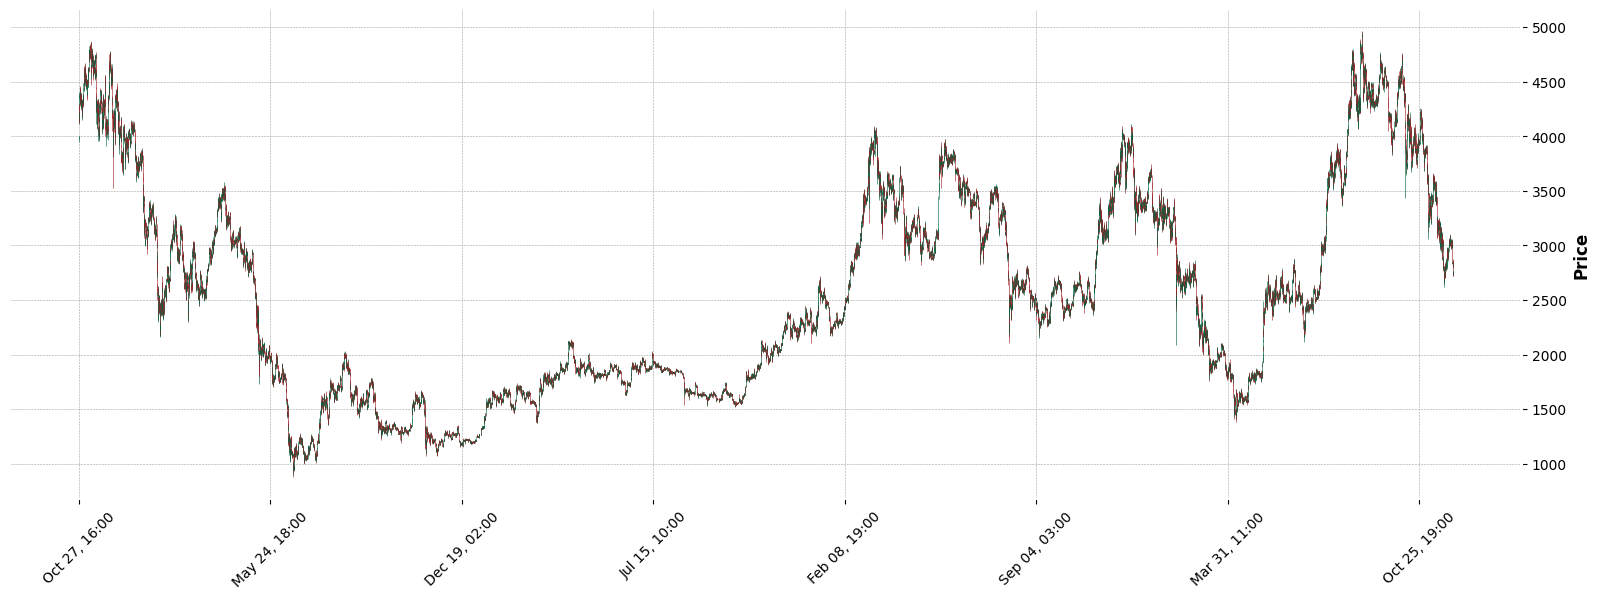

2021-10-27 16:00:00 2021-12-26 16:00:00
35890 1425
TO DO: Si quedan pocos soportes activos (no ejecutados)....menor a un umbral....entrar aquí también
N-M 20 50
p_min y p_max 3521.83 4834.93
len all posibles soluciones (N+M)  70
L(N) * L(M) 20 50 1000
Evaluar cortar despues de un tiempo o si la FO no mejora más que alpha %
TO DO: Poner los parámetros asociados en cada curva, ej y = izq + lambda * der....w = t ** n...


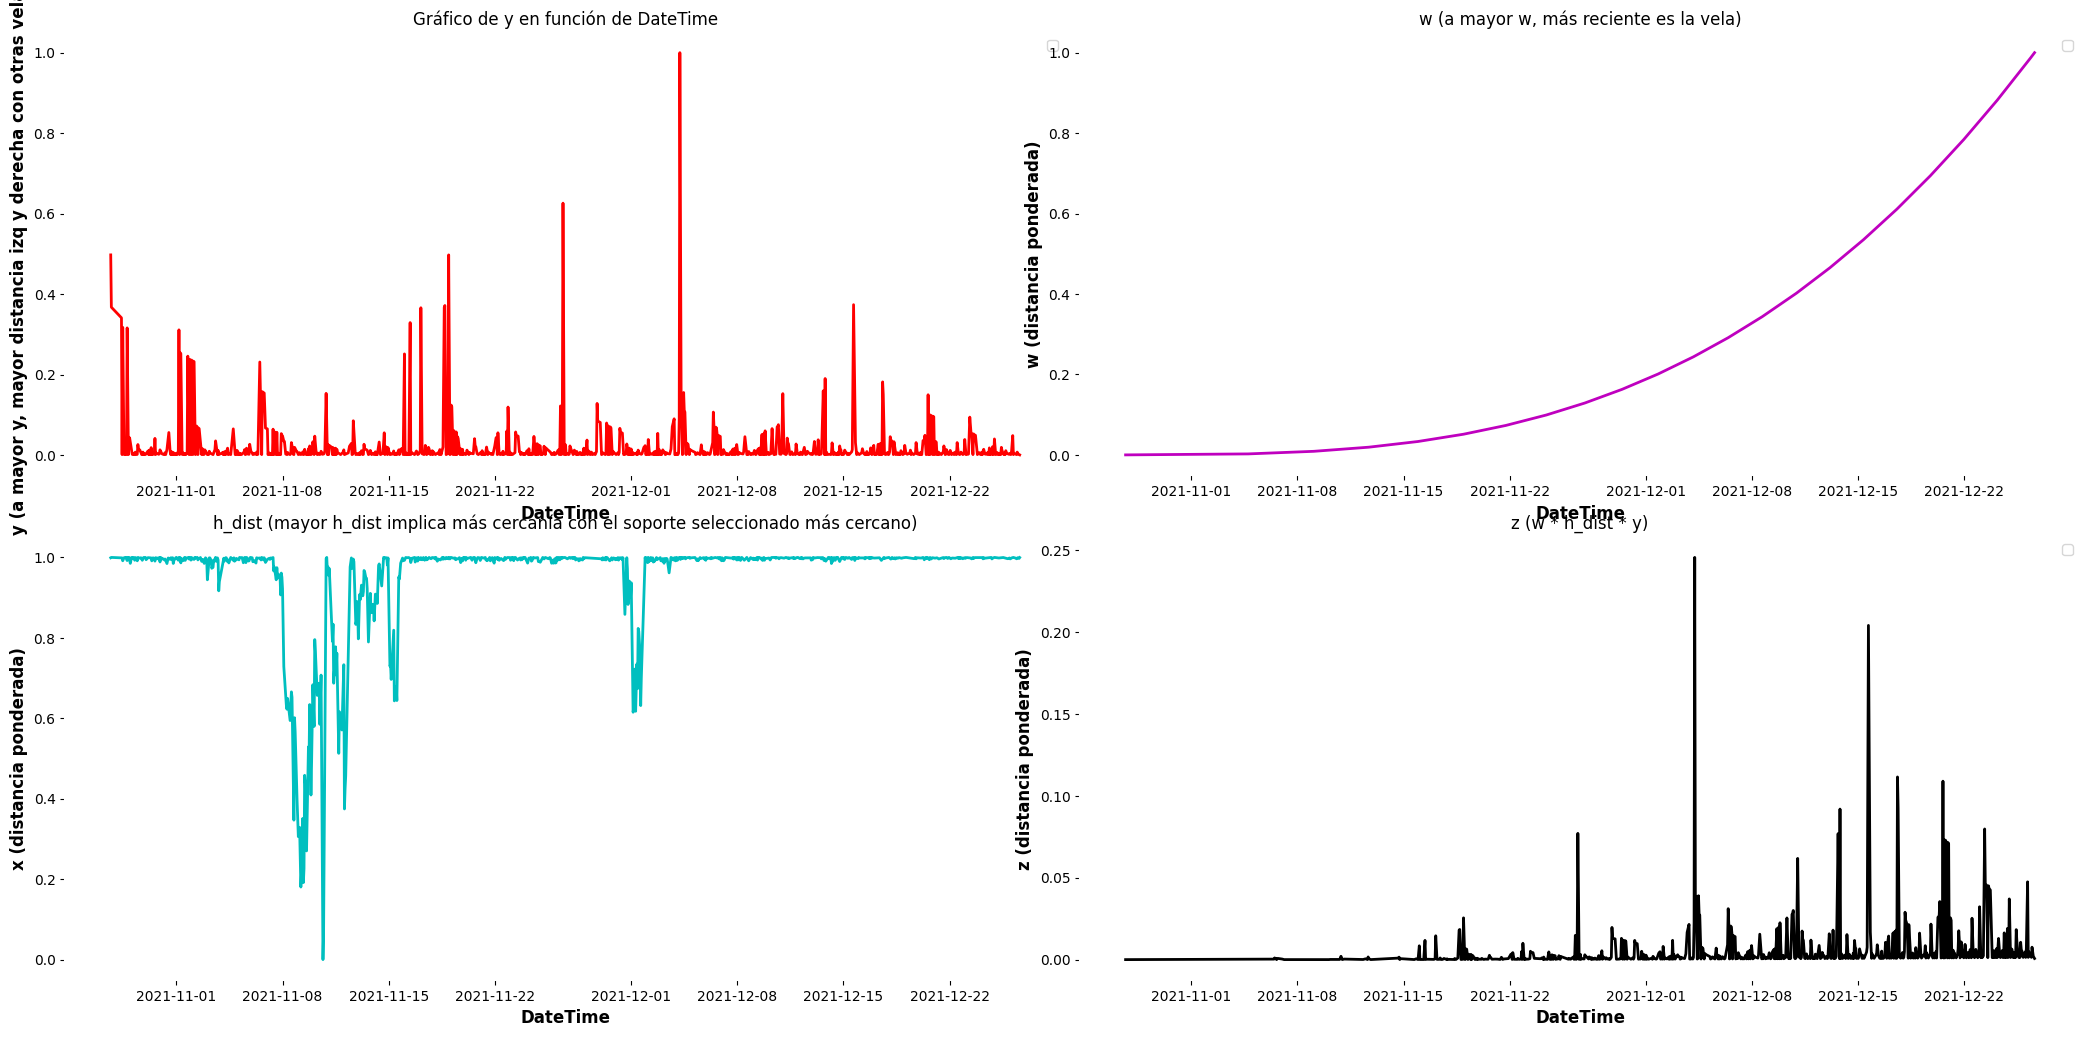

'df_extremos'

,DateTime,Open,High,Low,Close,Tick_Volume,Spread,Real_Volume,t,Low_left,Low_right,y,w,Soporte,dist,h_dist,z
0,2021-10-27 16:00:00,3975.23,3997.24,3949.80,3978.40,6258,39,0,0.000000,0.000000,0.497568,0.497568,0.000000e+00,3940.499565,86.498087,0.999067,0.000000e+00
1,2021-10-27 17:00:00,3978.40,4005.37,3976.33,3995.36,4345,39,0,0.000695,0.000695,0.366921,0.367616,3.355967e-10,3978.560435,4.974839,0.999946,1.233642e-10
2,2021-10-28 09:00:00,4118.85,4161.64,4109.15,4161.54,2528,268,0,0.011814,0.011814,0.329395,0.341209,1.648786e-06,4092.743043,269.188222,0.997097,5.609476e-07
3,2021-10-28 10:00:00,4162.30,4175.11,4138.99,4148.59,3998,268,0,0.012509,0.000695,0.000695,0.001390,1.957200e-06,4149.834348,117.599880,0.998732,2.716771e-09
4,2021-10-28 11:00:00,4148.42,4157.73,4120.62,4153.45,3895,247,0,0.013204,0.001390,0.316192,0.317582,2.301857e-06,4092.743043,777.124705,0.991618,7.249001e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1420,2021-12-26 11:00:00,4048.88,4057.42,4013.72,4033.30,5454,407,0,0.997220,0.004864,0.002780,0.007644,9.916840e-01,4016.621304,8.417567,0.999909,7.579940e-03
1421,2021-12-26 12:00:00,4033.45,4051.20,4024.97,4045.76,4958,421,0,0.997915,0.000695,0.002085,0.002780,9.937587e-01,4016.621304,69.700719,0.999248,2.760282e-03
1422,2021-12-26 13:00:00,4046.02,4050.06,4038.33,4045.39,4392,400,0,0.998610,0.000695,0.001390,0.002085,9.958362e-01,4054.682174,267.393592,0.997116,2.070113e-03
1423,2021-12-26 14:00:00,4045.43,4055.13,4039.00,4052.45,4469,396,0,0.999305,0.000695,0.000695,0.001390,9.979167e-01,4054.682174,245.930579,0.997347,1.383279e-03


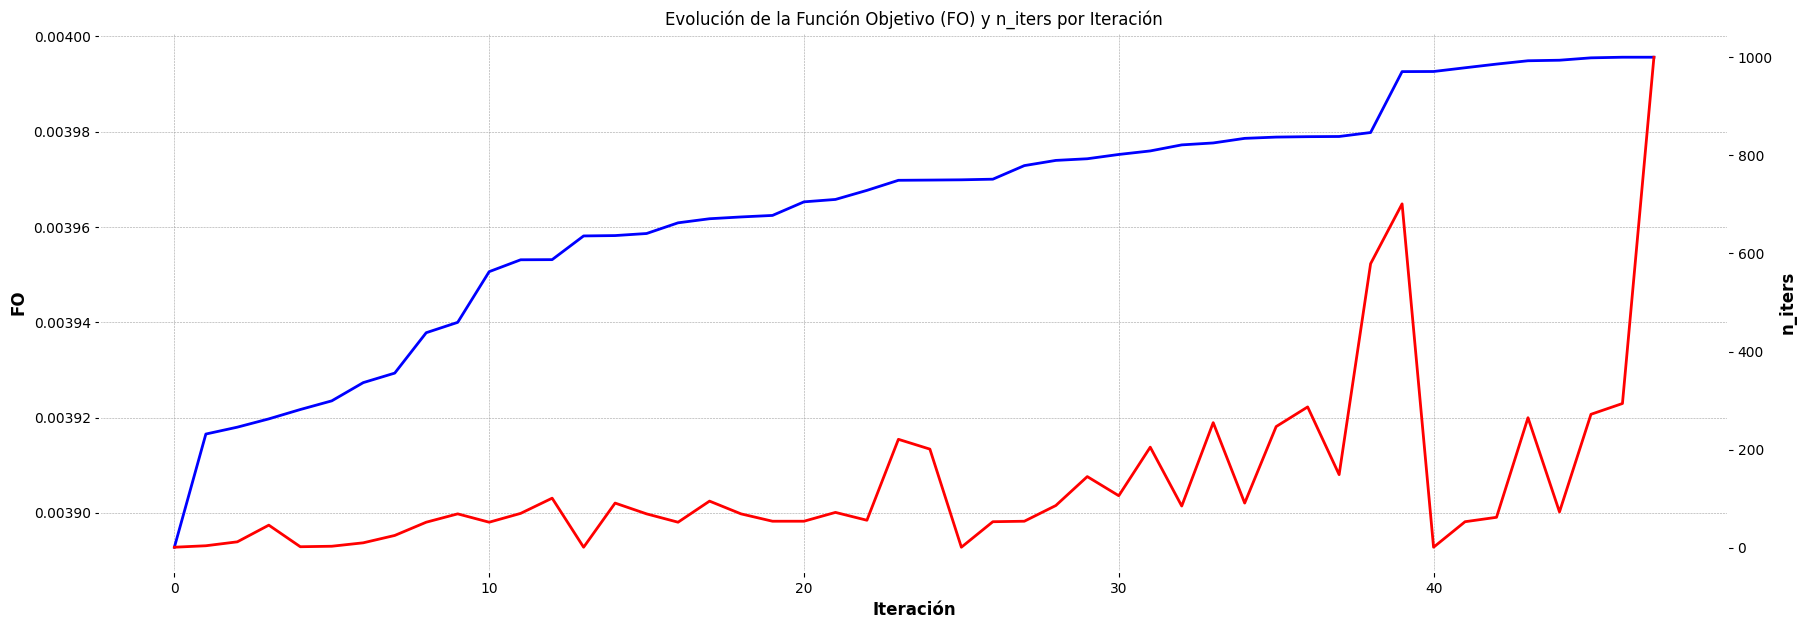

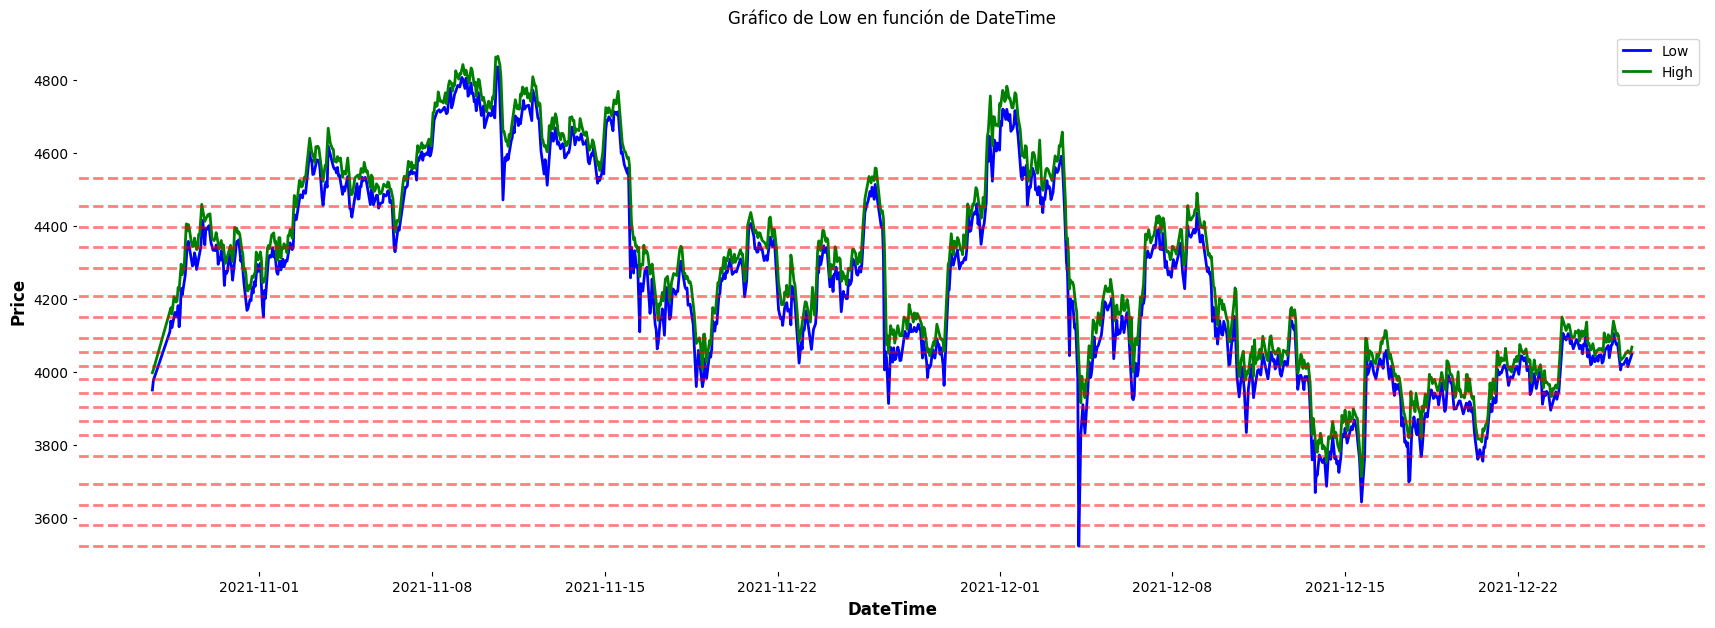

delta trigger y cambio SL 1 1
Actualización periódica de OC


'df_oc_all base inicial'

""


'df_oc_all base final'

,periodo,ultimo_cierre,id,tipo_oc,n,beta,cambio_SL,trigger,SL_LP,Status,Monto Compra (lotes),Valor_actual
0,2021-12-26 15:00:00,4054.16,1,I,3521.830000,4.600940,NaN,3521.830000,3252.819702,Activa,NaN,0
1,2021-12-26 15:00:00,4054.16,2,I,3978.560435,4.388713,NaN,3978.560435,3709.550137,Activa,NaN,0
2,2021-12-26 15:00:00,4054.16,3,I,3769.225652,4.485984,NaN,3769.225652,3500.215354,Activa,NaN,0
3,2021-12-26 15:00:00,4054.16,4,S,4054.682174,4.353342,4095.228996,4136.181286,3785.671876,Activa,NaN,0
4,2021-12-26 15:00:00,4054.16,5,I,3864.377826,4.441770,NaN,3864.377826,3595.367528,Activa,NaN,0
5,2021-12-26 15:00:00,4054.16,6,I,3940.499565,4.406399,NaN,3940.499565,3671.489267,Activa,NaN,0
6,2021-12-26 15:00:00,4054.16,7,S,4454.321304,4.167643,4498.864517,4543.853163,4185.311006,Activa,NaN,0
7,2021-12-26 15:00:00,4054.16,8,S,4397.230000,4.194171,4441.202300,4485.614323,4128.219702,Activa,NaN,0
8,2021-12-26 15:00:00,4054.16,9,I,3693.103913,4.521355,NaN,3693.103913,3424.093615,Activa,NaN,0
9,2021-12-26 15:00:00,4054.16,10,S,4206.925652,4.282599,4248.994909,4291.484858,3937.915354,Activa,NaN,0


Continuar aquí 251028
Desarrollar actualizar valor de ordenes abiertas en df_oc_all y cuenta_size
Ejecución de orden 4003.44 4016.621304347826 4039.02
N-M 20 50
p_min y p_max 3521.83 4834.93
L(N) * L(M) 20 50 1000
Evaluar cortar despues de un tiempo o si la FO no mejora más que alpha %
TO DO: Poner los parámetros asociados en cada curva, ej y = izq + lambda * der....w = t ** n...


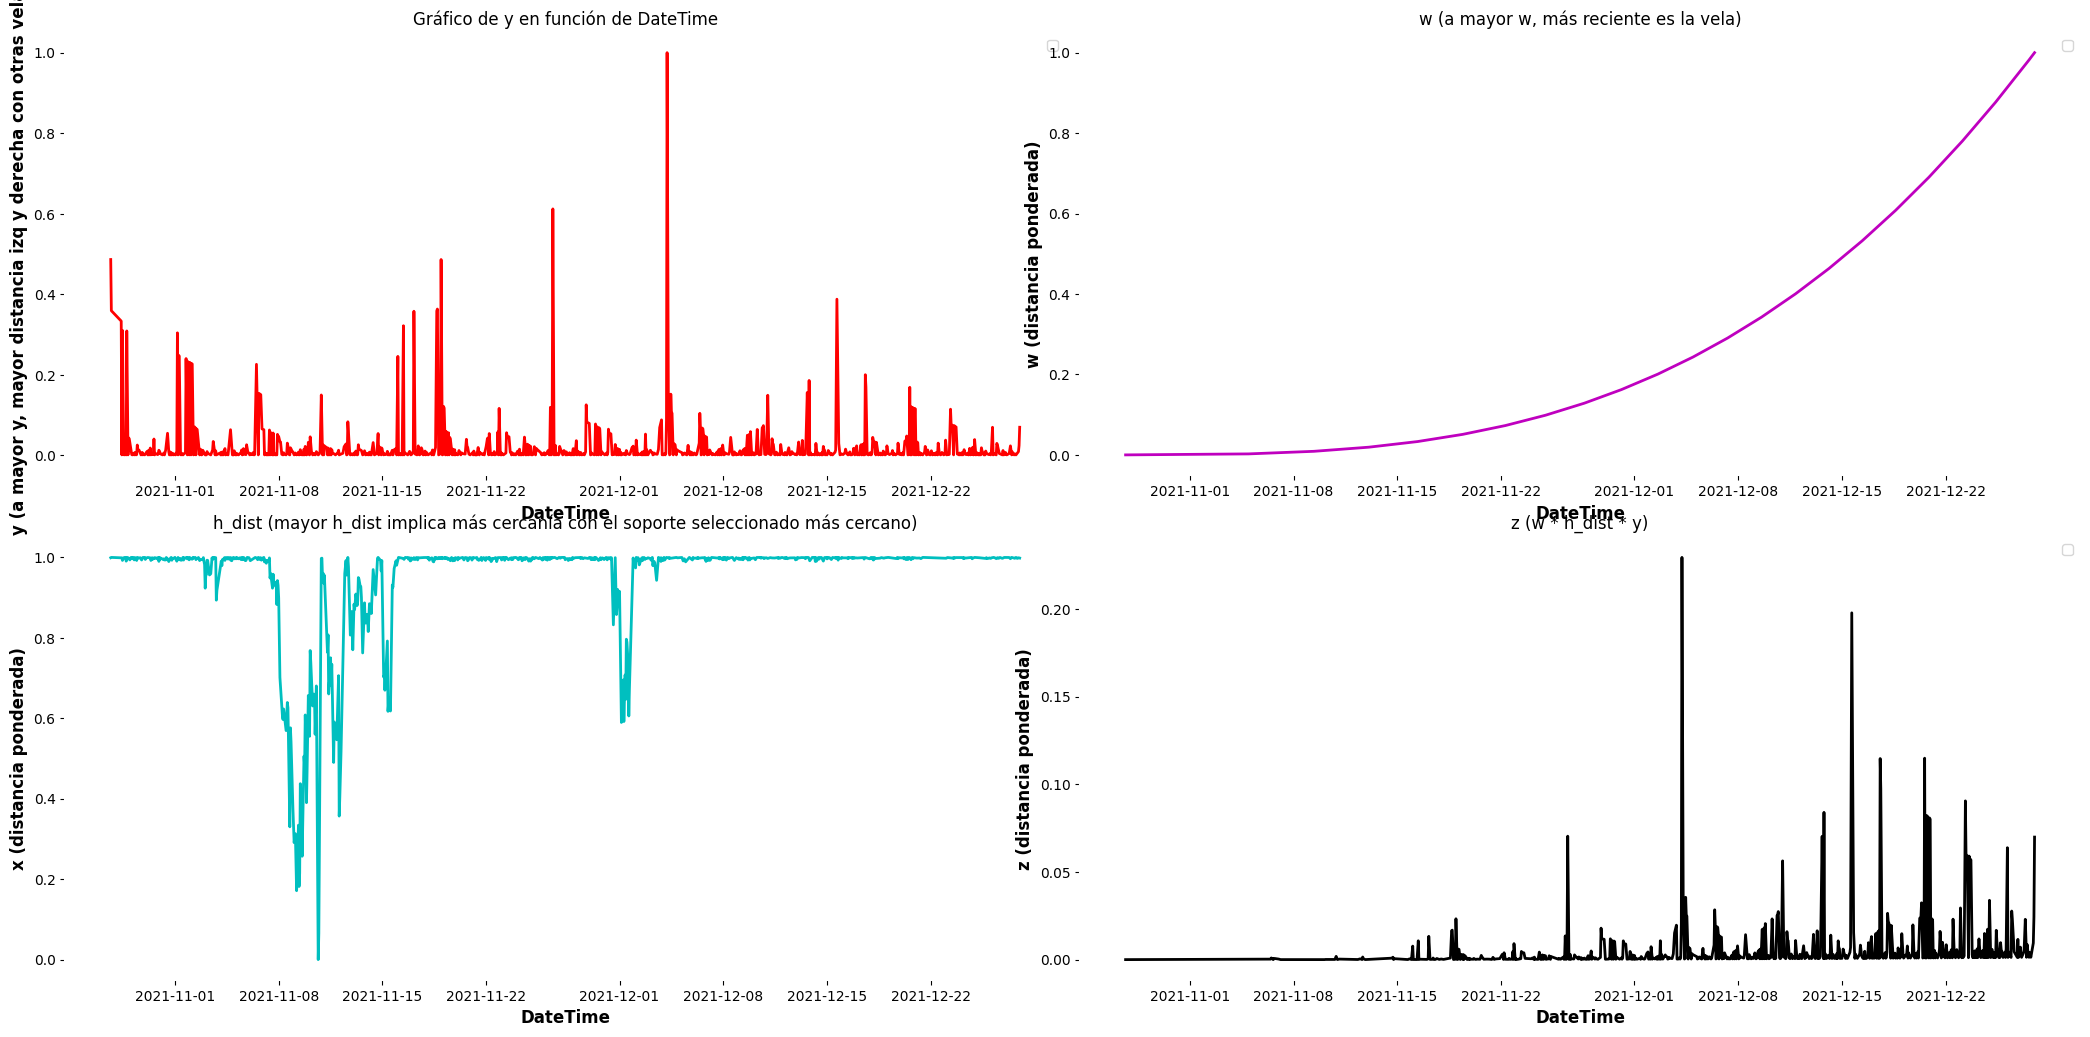

'df_extremos'

,DateTime,Open,High,Low,Close,Tick_Volume,Spread,Real_Volume,t,Low_left,Low_right,y,w,Soporte,dist,h_dist,z
0,2021-10-27 16:00:00,3975.23,3997.24,3949.80,3978.40,6258,39,0,0.000000,0.000000,0.486413,0.486413,0.000000e+00,3940.499565,86.498087,0.999164,0.000000e+00
1,2021-10-27 17:00:00,3978.40,4005.37,3976.33,3995.36,4345,39,0,0.000679,0.000679,0.358696,0.359375,3.135282e-10,3978.560435,4.974839,0.999952,1.126688e-10
2,2021-10-28 09:00:00,4118.85,4161.64,4109.15,4161.54,2528,268,0,0.011549,0.011549,0.322011,0.333560,1.540364e-06,4092.743043,269.188222,0.997397,5.124660e-07
3,2021-10-28 10:00:00,4162.30,4175.11,4138.99,4148.59,3998,268,0,0.012228,0.000679,0.000679,0.001359,1.828496e-06,4149.834348,117.599880,0.998863,2.481545e-09
4,2021-10-28 11:00:00,4148.42,4157.73,4120.62,4153.45,3895,247,0,0.012908,0.001359,0.309103,0.310462,2.150490e-06,4092.743043,777.124705,0.992485,6.626279e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,2021-12-27 20:00:00,4079.85,4093.32,4070.93,4091.23,5189,338,0,0.997283,0.005435,0.000679,0.006114,9.918700e-01,4054.682174,263.991853,0.997447,6.048941e-03
1454,2021-12-27 21:00:00,4091.29,4092.68,4057.61,4058.95,4486,336,0,0.997962,0.006114,0.000679,0.006793,9.938983e-01,4054.682174,8.572166,0.999917,6.751467e-03
1455,2021-12-27 22:00:00,4059.21,4074.86,4045.33,4062.15,4336,342,0,0.998641,0.008832,0.000679,0.009511,9.959294e-01,4054.682174,87.463157,0.999154,9.464144e-03
1456,2021-12-27 23:00:00,4062.25,4067.74,4032.42,4038.53,5740,374,0,0.999321,0.023777,0.000679,0.024457,9.979633e-01,4016.621304,249.598784,0.997586,2.434780e-02


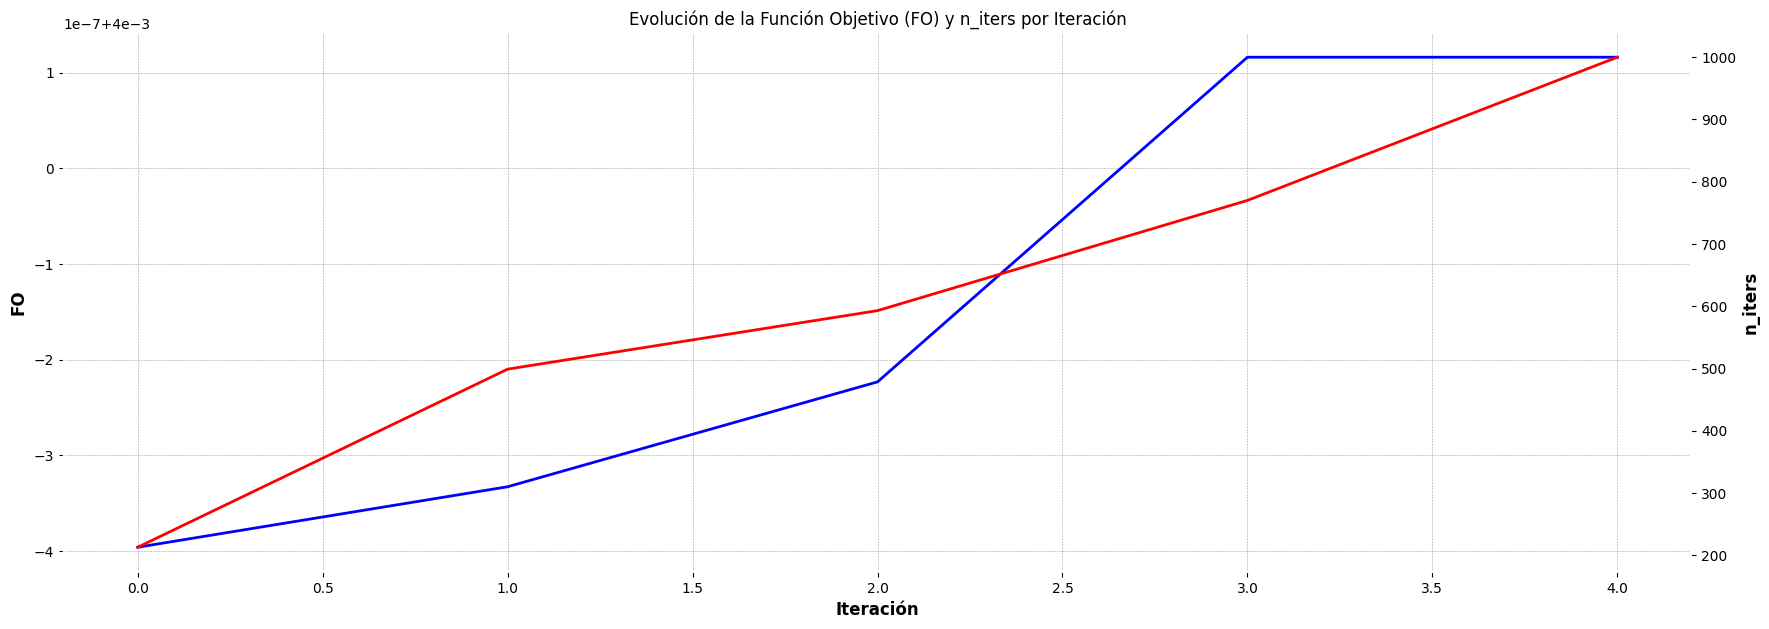

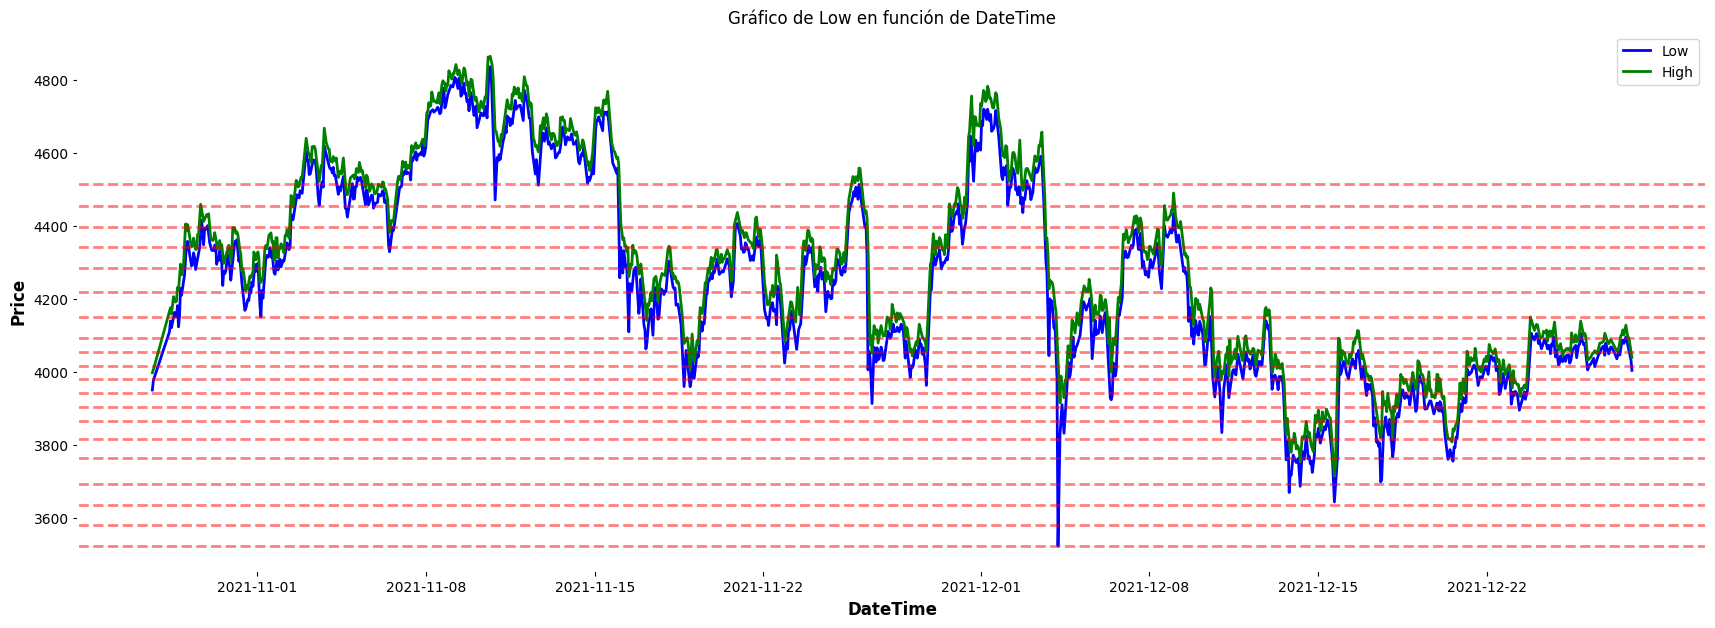

delta trigger y cambio SL 1 1
Actualización reemplazo de OC 33


'df_oc_all base inicial'

,periodo,ultimo_cierre,id,tipo_oc,n,beta,cambio_SL,trigger,SL_LP,Status,Monto Compra (lotes),Valor_actual
0,2021-12-26 15:00:00,4054.16,1,I,3521.830000,4.600940,NaN,3521.830000,3252.819702,Activa,NaN,0
1,2021-12-26 15:00:00,4054.16,2,I,3978.560435,4.388713,NaN,3978.560435,3709.550137,Activa,NaN,0
2,2021-12-26 15:00:00,4054.16,3,I,3769.225652,4.485984,NaN,3769.225652,3500.215354,Activa,NaN,0
3,2021-12-26 15:00:00,4054.16,4,S,4054.682174,4.353342,4095.228996,4136.181286,3785.671876,Activa,NaN,0
4,2021-12-26 15:00:00,4054.16,5,I,3864.377826,4.441770,NaN,3864.377826,3595.367528,Activa,NaN,0
5,2021-12-26 15:00:00,4054.16,6,I,3940.499565,4.406399,NaN,3940.499565,3671.489267,Activa,NaN,0
6,2021-12-26 15:00:00,4054.16,7,S,4454.321304,4.167643,4498.864517,4543.853163,4185.311006,Activa,NaN,0
7,2021-12-26 15:00:00,4054.16,8,S,4397.230000,4.194171,4441.202300,4485.614323,4128.219702,Activa,NaN,0
8,2021-12-26 15:00:00,4054.16,9,I,3693.103913,4.521355,NaN,3693.103913,3424.093615,Activa,NaN,0
9,2021-12-26 15:00:00,4054.16,10,S,4206.925652,4.282599,4248.994909,4291.484858,3937.915354,Activa,NaN,0


'df_oc_all base final'

,periodo,ultimo_cierre,id,tipo_oc,n,beta,cambio_SL,trigger,SL_LP,Status,Monto Compra (lotes),Valor_actual
0,2021-12-26 15:00:00,4054.16,1,I,3521.830000,4.600940,NaN,3521.830000,3252.819702,Activa,NaN,0
1,2021-12-26 15:00:00,4054.16,2,I,3978.560435,4.388713,NaN,3978.560435,3709.550137,Activa,NaN,0
2,2021-12-26 15:00:00,4054.16,3,I,3769.225652,4.485984,NaN,3769.225652,3500.215354,Inactiva,NaN,0
3,2021-12-26 15:00:00,4054.16,4,S,4054.682174,4.353342,4095.228996,4136.181286,3785.671876,Activa,NaN,0
4,2021-12-26 15:00:00,4054.16,5,I,3864.377826,4.441770,NaN,3864.377826,3595.367528,Activa,NaN,0
5,2021-12-26 15:00:00,4054.16,6,I,3940.499565,4.406399,NaN,3940.499565,3671.489267,Activa,NaN,0
6,2021-12-26 15:00:00,4054.16,7,S,4454.321304,4.167643,4498.864517,4543.853163,4185.311006,Activa,NaN,0
7,2021-12-26 15:00:00,4054.16,8,S,4397.230000,4.194171,4441.202300,4485.614323,4128.219702,Activa,NaN,0
8,2021-12-26 15:00:00,4054.16,9,I,3693.103913,4.521355,NaN,3693.103913,3424.093615,Activa,NaN,0
9,2021-12-26 15:00:00,4054.16,10,S,4206.925652,4.282599,4248.994909,4291.484858,3937.915354,Inactiva,NaN,0


Ejecución de orden 3969.41 3978.560434782609 4030.55
Ejecución de orden 3969.41 4016.621304347826 4030.55
N-M 20 50
p_min y p_max 3521.83 4834.93
L(N) * L(M) 20 50 1000
Evaluar cortar despues de un tiempo o si la FO no mejora más que alpha %
TO DO: Poner los parámetros asociados en cada curva, ej y = izq + lambda * der....w = t ** n...


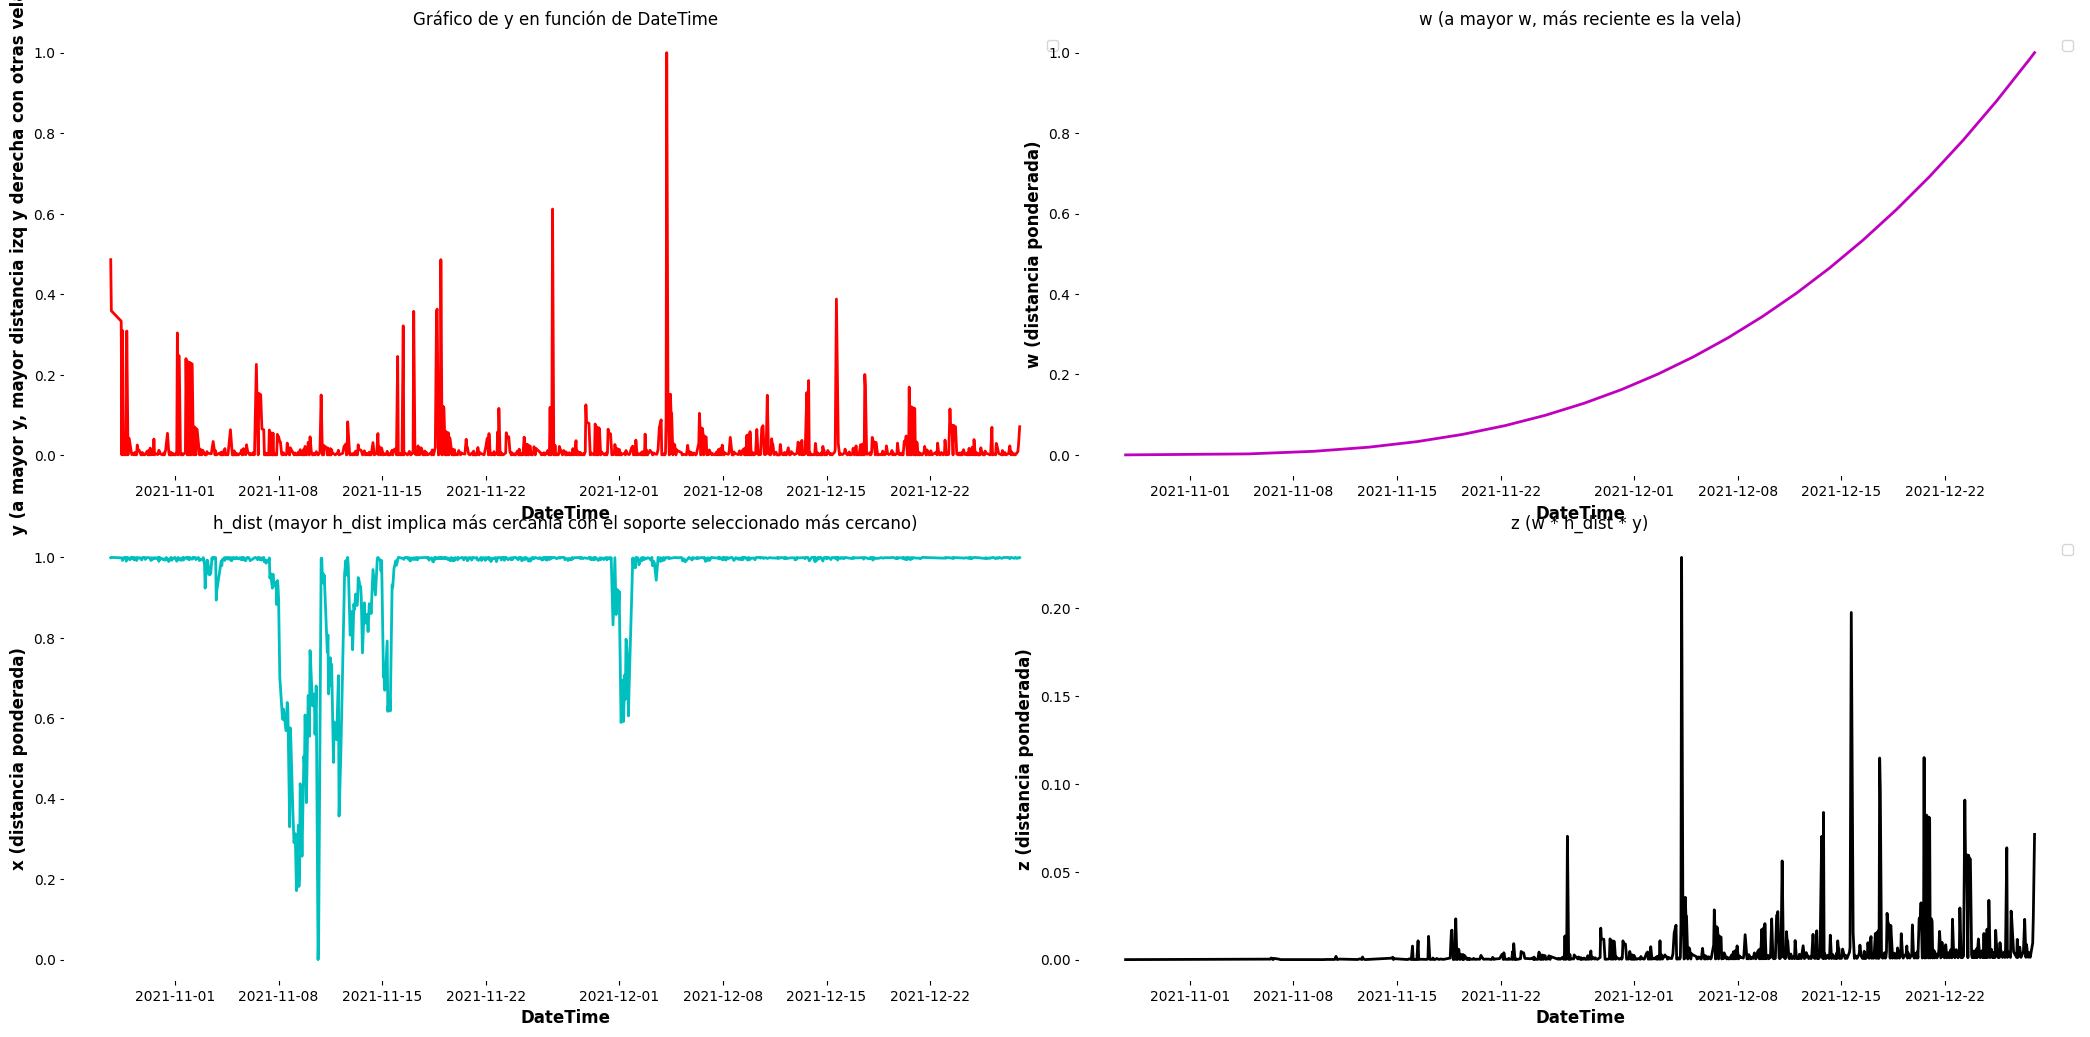

'df_extremos'

,DateTime,Open,High,Low,Close,Tick_Volume,Spread,Real_Volume,t,Low_left,Low_right,y,w,Soporte,dist,h_dist,z
0,2021-10-27 16:00:00,3975.23,3997.24,3949.80,3978.40,6258,39,0,0.000000,0.000000,0.486083,0.486083,0.000000e+00,3940.499565,86.498087,0.999164,0.000000e+00
1,2021-10-27 17:00:00,3978.40,4005.37,3976.33,3995.36,4345,39,0,0.000679,0.000679,0.358452,0.359131,3.128901e-10,3977.395306,1.134877,0.999989,1.123673e-10
2,2021-10-28 09:00:00,4118.85,4161.64,4109.15,4161.54,2528,268,0,0.011541,0.011541,0.321792,0.333333,1.537229e-06,4092.743043,269.188222,0.997397,5.110758e-07
3,2021-10-28 10:00:00,4162.30,4175.11,4138.99,4148.59,3998,268,0,0.012220,0.000679,0.000679,0.001358,1.824775e-06,4149.834348,117.599880,0.998863,2.474813e-09
4,2021-10-28 11:00:00,4148.42,4157.73,4120.62,4153.45,3895,247,0,0.012899,0.001358,0.308893,0.310251,2.146113e-06,4092.743043,777.124705,0.992485,6.608304e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2021-12-27 21:00:00,4091.29,4092.68,4057.61,4058.95,4486,336,0,0.997284,0.006110,0.000679,0.006789,9.918755e-01,4054.682174,8.572166,0.999917,6.733152e-03
1455,2021-12-27 22:00:00,4059.21,4074.86,4045.33,4062.15,4336,342,0,0.997963,0.008826,0.000679,0.009504,9.939025e-01,4054.682174,87.463157,0.999154,9.438470e-03
1456,2021-12-27 23:00:00,4062.25,4067.74,4032.42,4038.53,5740,374,0,0.998642,0.023761,0.000679,0.024440,9.959322e-01,4016.621304,249.598784,0.997586,2.428175e-02
1457,2021-12-28 00:00:00,4038.78,4039.02,4003.44,4030.57,6698,404,0,0.999321,0.069925,0.000679,0.070604,9.979647e-01,4016.621304,173.746784,0.998320,7.034212e-02


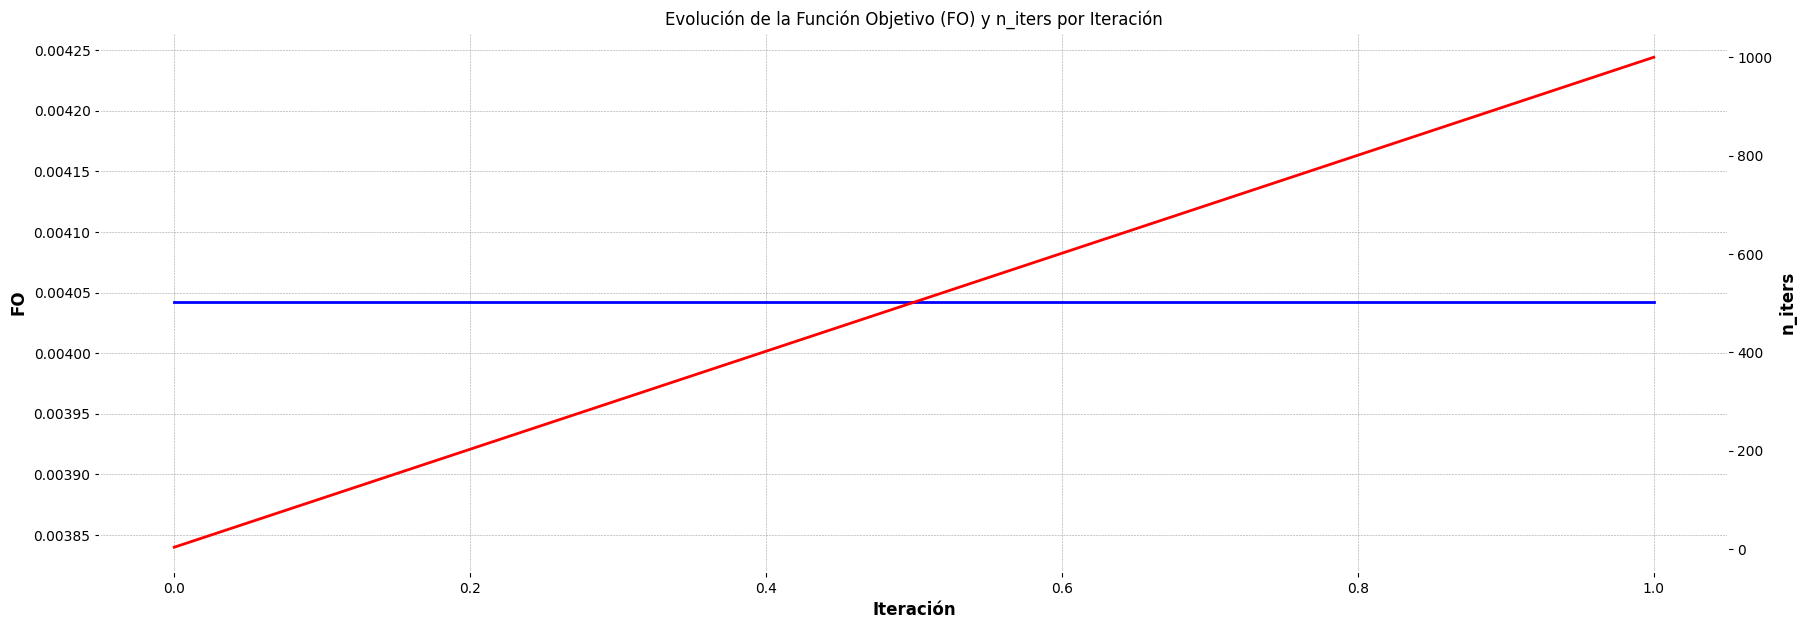

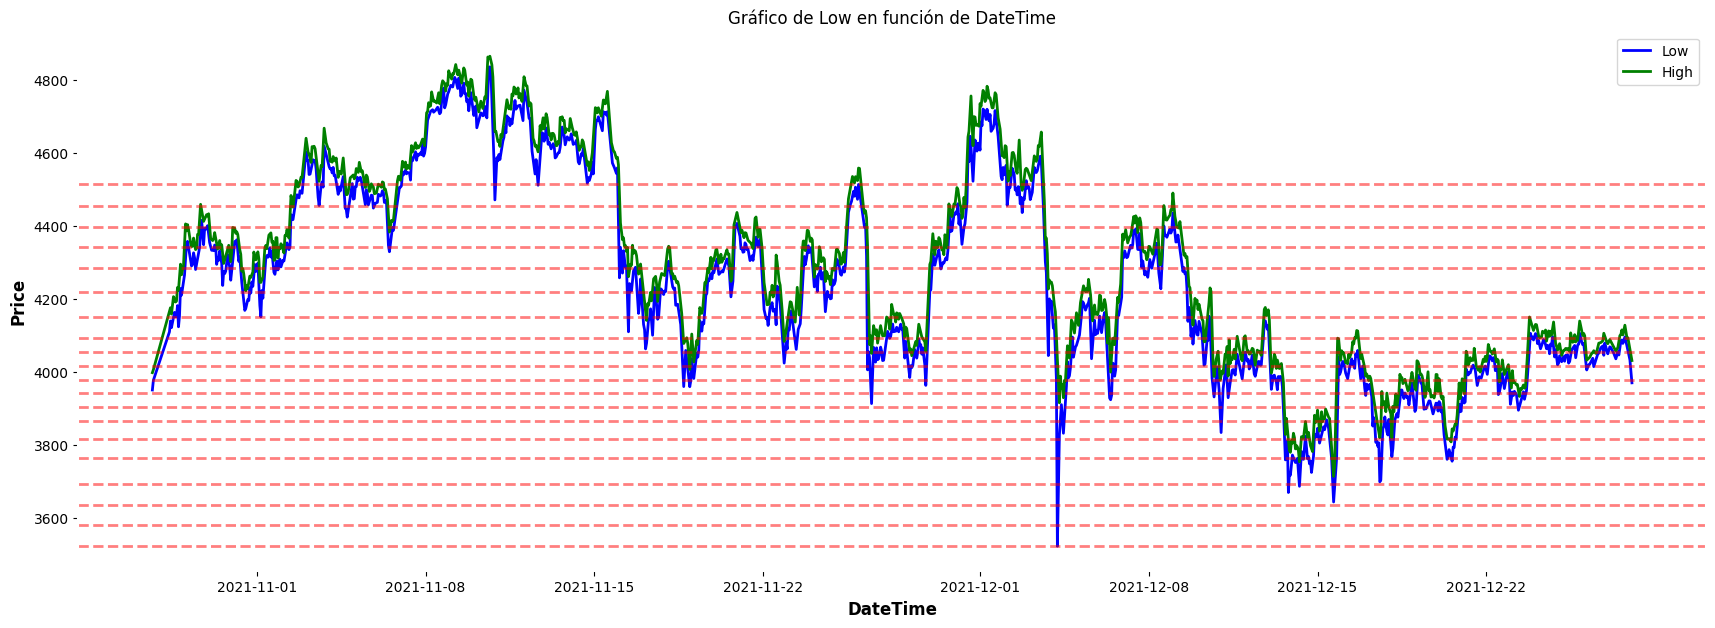

delta trigger y cambio SL 1 1
Actualización reemplazo de OC 34


'df_oc_all base inicial'

,periodo,ultimo_cierre,id,tipo_oc,n,beta,cambio_SL,trigger,SL_LP,Status,Monto Compra (lotes),Valor_actual
0,2021-12-26 15:00:00,4054.16,1,I,3521.830000,4.600940,NaN,3521.830000,3252.819702,Activa,NaN,0
1,2021-12-26 15:00:00,4054.16,2,I,3978.560435,4.388713,NaN,3978.560435,3649.406965,Abierta,0.4,0
2,2021-12-26 15:00:00,4054.16,3,I,3769.225652,4.485984,NaN,3769.225652,3500.215354,Inactiva,NaN,0
3,2021-12-26 15:00:00,4054.16,4,S,4054.682174,4.353342,4095.228996,4136.181286,3785.671876,Activa,NaN,0
4,2021-12-26 15:00:00,4054.16,5,I,3864.377826,4.441770,NaN,3864.377826,3595.367528,Activa,NaN,0
5,2021-12-26 15:00:00,4054.16,6,I,3940.499565,4.406399,NaN,3940.499565,3671.489267,Activa,NaN,0
6,2021-12-26 15:00:00,4054.16,7,S,4454.321304,4.167643,4498.864517,4543.853163,4185.311006,Activa,NaN,0
7,2021-12-26 15:00:00,4054.16,8,S,4397.230000,4.194171,4441.202300,4485.614323,4128.219702,Activa,NaN,0
8,2021-12-26 15:00:00,4054.16,9,I,3693.103913,4.521355,NaN,3693.103913,3424.093615,Activa,NaN,0
9,2021-12-26 15:00:00,4054.16,10,S,4206.925652,4.282599,4248.994909,4291.484858,3937.915354,Inactiva,NaN,0


'df_oc_all base final'

,periodo,ultimo_cierre,id,tipo_oc,n,beta,cambio_SL,trigger,SL_LP,Status,Monto Compra (lotes),Valor_actual
0,2021-12-26 15:00:00,4054.16,1,I,3521.830000,4.600940,NaN,3521.830000,3252.819702,Activa,NaN,0
1,2021-12-26 15:00:00,4054.16,2,I,3978.560435,4.388713,NaN,3978.560435,3649.406965,Abierta,0.4,0
2,2021-12-26 15:00:00,4054.16,3,I,3769.225652,4.485984,NaN,3769.225652,3500.215354,Inactiva,NaN,0
3,2021-12-26 15:00:00,4054.16,4,S,4054.682174,4.353342,4095.228996,4136.181286,3785.671876,Activa,NaN,0
4,2021-12-26 15:00:00,4054.16,5,I,3864.377826,4.441770,NaN,3864.377826,3595.367528,Activa,NaN,0
5,2021-12-26 15:00:00,4054.16,6,I,3940.499565,4.406399,NaN,3940.499565,3671.489267,Activa,NaN,0
6,2021-12-26 15:00:00,4054.16,7,S,4454.321304,4.167643,4498.864517,4543.853163,4185.311006,Activa,NaN,0
7,2021-12-26 15:00:00,4054.16,8,S,4397.230000,4.194171,4441.202300,4485.614323,4128.219702,Activa,NaN,0
8,2021-12-26 15:00:00,4054.16,9,I,3693.103913,4.521355,NaN,3693.103913,3424.093615,Activa,NaN,0
9,2021-12-26 15:00:00,4054.16,10,S,4206.925652,4.282599,4248.994909,4291.484858,3937.915354,Inactiva,NaN,0


Ejecución de orden 3958.59 3977.3953061224493 3995.6
N-M 20 50
p_min y p_max 3521.83 4834.93
L(N) * L(M) 20 50 1000
Evaluar cortar despues de un tiempo o si la FO no mejora más que alpha %
TO DO: Poner los parámetros asociados en cada curva, ej y = izq + lambda * der....w = t ** n...


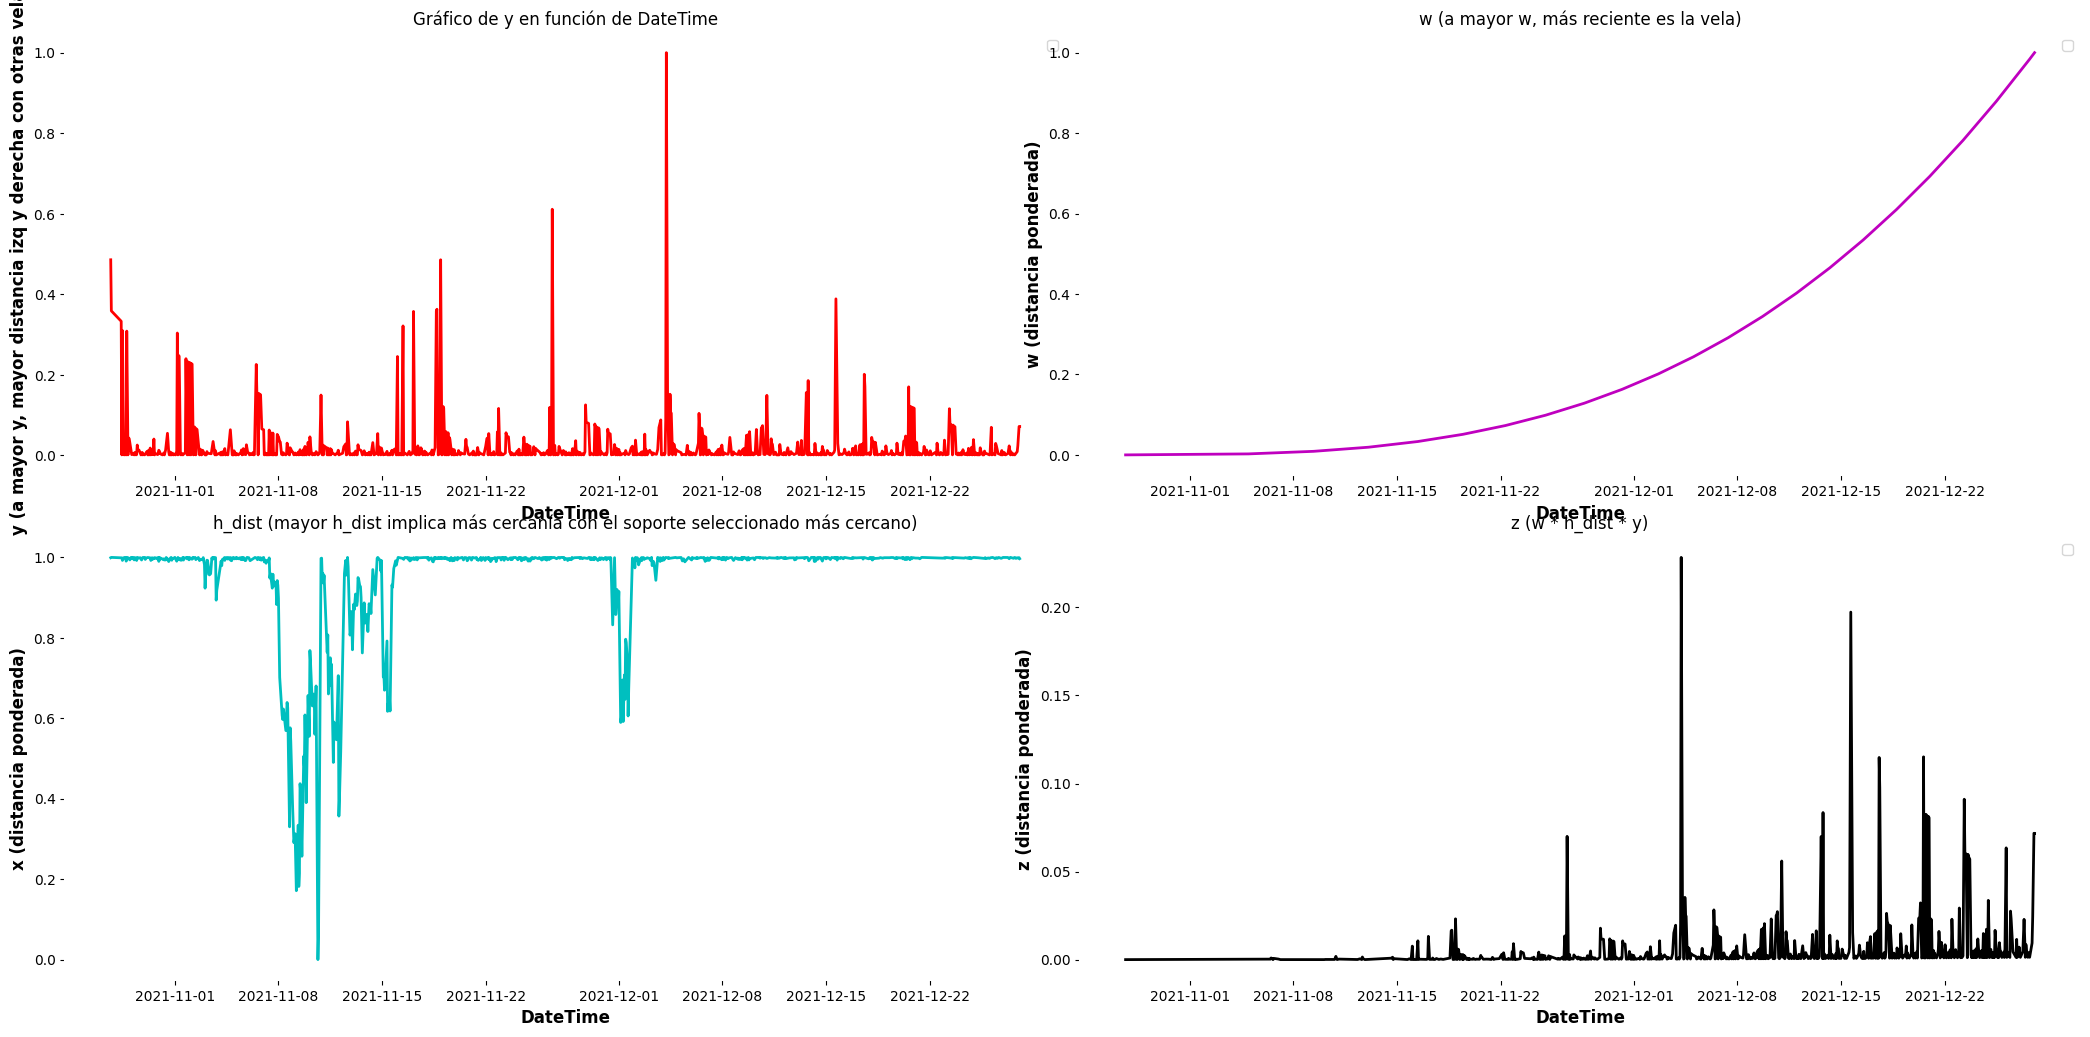

'df_extremos'

,DateTime,Open,High,Low,Close,Tick_Volume,Spread,Real_Volume,t,Low_left,Low_right,y,w,Soporte,dist,h_dist,z
0,2021-10-27 16:00:00,3975.23,3997.24,3949.80,3978.40,6258,39,0,0.000000,0.000000,0.485753,0.485753,0.000000e+00,3940.499565,86.498087,0.999164,0.000000e+00
1,2021-10-27 17:00:00,3978.40,4005.37,3976.33,3995.36,4345,39,0,0.000678,0.000678,0.358209,0.358887,3.122537e-10,3977.395306,1.134877,0.999989,1.120627e-10
2,2021-10-28 09:00:00,4118.85,4161.64,4109.15,4161.54,2528,268,0,0.011533,0.011533,0.321574,0.333107,1.534102e-06,4092.743043,269.188222,0.997397,5.096903e-07
3,2021-10-28 10:00:00,4162.30,4175.11,4138.99,4148.59,3998,268,0,0.012212,0.000678,0.000678,0.001357,1.821063e-06,4149.834348,117.599880,0.998863,2.468104e-09
4,2021-10-28 11:00:00,4148.42,4157.73,4120.62,4153.45,3895,247,0,0.012890,0.001357,0.308684,0.310041,2.141748e-06,4092.743043,777.124705,0.992485,6.590389e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,2021-12-27 22:00:00,4059.21,4074.86,4045.33,4062.15,4336,342,0,0.997286,0.008820,0.000678,0.009498,9.918810e-01,4054.682174,87.463157,0.999154,9.412882e-03
1456,2021-12-27 23:00:00,4062.25,4067.74,4032.42,4038.53,5740,374,0,0.997965,0.023745,0.000678,0.024423,9.939066e-01,4016.621304,249.598784,0.997586,2.421593e-02
1457,2021-12-28 00:00:00,4038.78,4039.02,4003.44,4030.57,6698,404,0,0.998643,0.069878,0.000678,0.070556,9.959350e-01,4016.621304,173.746784,0.998320,7.015143e-02
1458,2021-12-28 01:00:00,4030.55,4030.55,3969.41,3980.72,7525,408,0,0.999322,0.071235,0.000678,0.071913,9.979661e-01,3977.395306,63.765114,0.999383,7.172264e-02


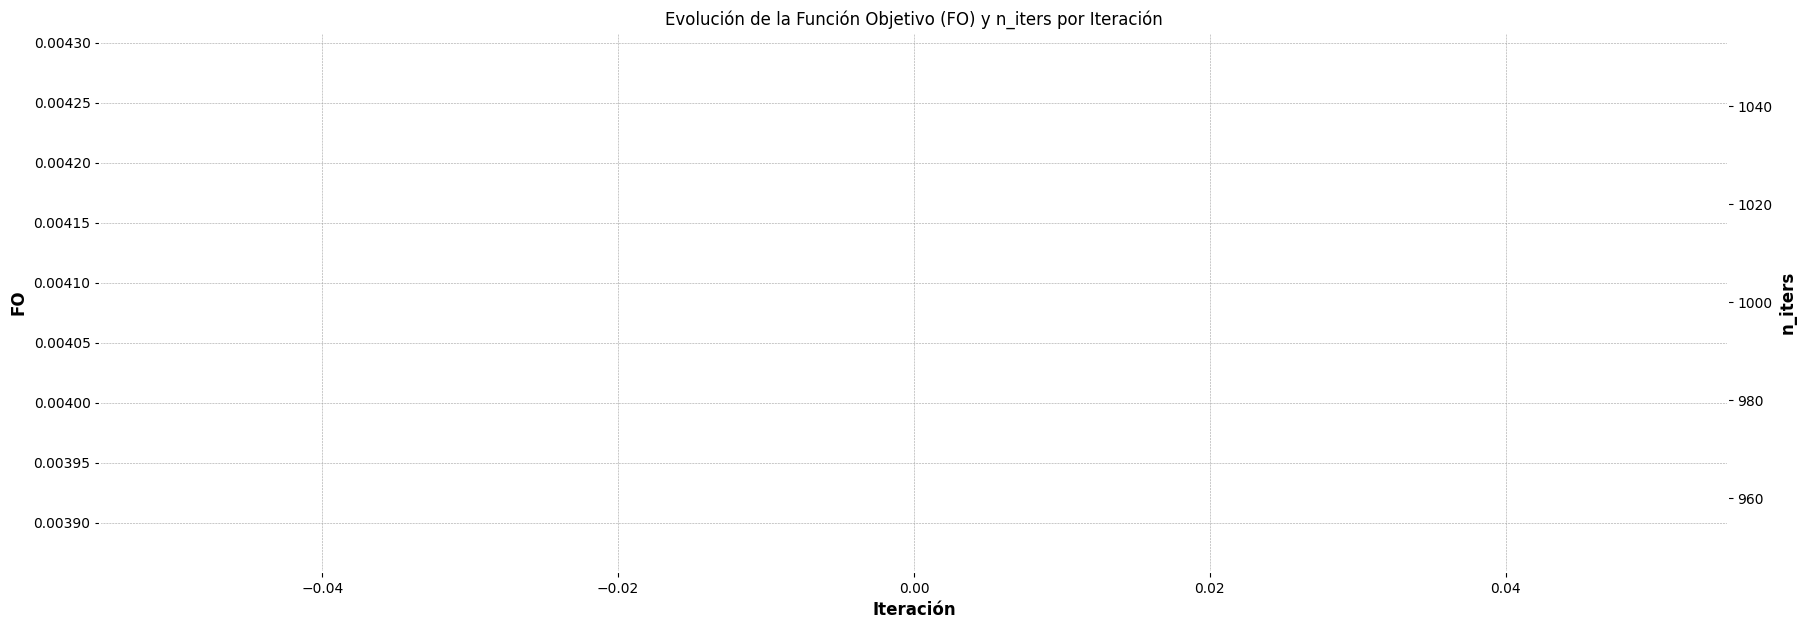

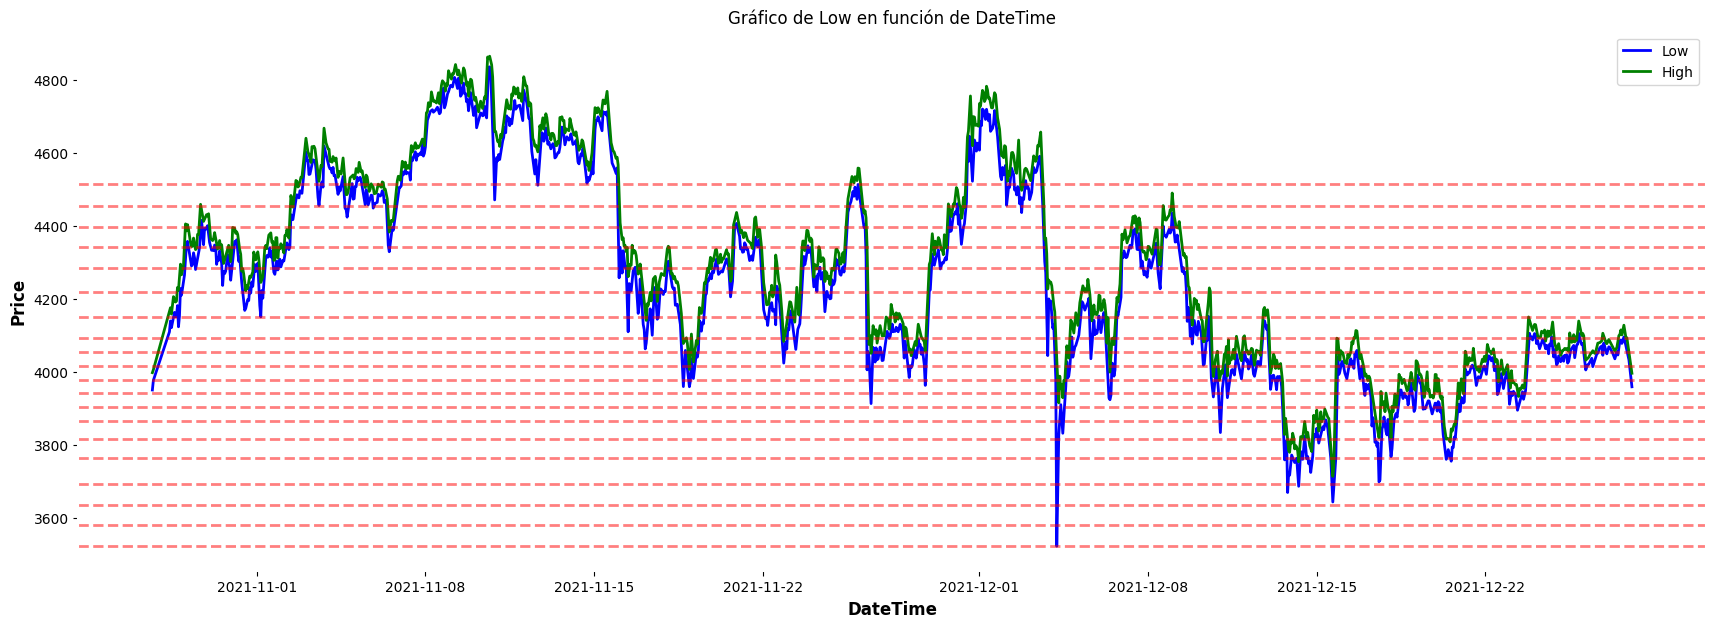

delta trigger y cambio SL 1 1
Actualización reemplazo de OC 35


'df_oc_all base inicial'

,periodo,ultimo_cierre,id,tipo_oc,n,beta,cambio_SL,trigger,SL_LP,Status,Monto Compra (lotes),Valor_actual
0,2021-12-26 15:00:00,4054.16,1,I,3521.830000,4.600940,NaN,3521.830000,3252.819702,Activa,NaN,0
1,2021-12-26 15:00:00,4054.16,2,I,3978.560435,4.388713,NaN,3978.560435,3649.406965,Abierta,0.4,0
2,2021-12-26 15:00:00,4054.16,3,I,3769.225652,4.485984,NaN,3769.225652,3500.215354,Inactiva,NaN,0
3,2021-12-26 15:00:00,4054.16,4,S,4054.682174,4.353342,4095.228996,4136.181286,3785.671876,Activa,NaN,0
4,2021-12-26 15:00:00,4054.16,5,I,3864.377826,4.441770,NaN,3864.377826,3595.367528,Activa,NaN,0
5,2021-12-26 15:00:00,4054.16,6,I,3940.499565,4.406399,NaN,3940.499565,3671.489267,Activa,NaN,0
6,2021-12-26 15:00:00,4054.16,7,S,4454.321304,4.167643,4498.864517,4543.853163,4185.311006,Activa,NaN,0
7,2021-12-26 15:00:00,4054.16,8,S,4397.230000,4.194171,4441.202300,4485.614323,4128.219702,Activa,NaN,0
8,2021-12-26 15:00:00,4054.16,9,I,3693.103913,4.521355,NaN,3693.103913,3424.093615,Activa,NaN,0
9,2021-12-26 15:00:00,4054.16,10,S,4206.925652,4.282599,4248.994909,4291.484858,3937.915354,Inactiva,NaN,0


'df_oc_all base final'

,periodo,ultimo_cierre,id,tipo_oc,n,beta,cambio_SL,trigger,SL_LP,Status,Monto Compra (lotes),Valor_actual
0,2021-12-26 15:00:00,4054.16,1,I,3521.830000,4.600940,NaN,3521.830000,3252.819702,Activa,NaN,0
1,2021-12-26 15:00:00,4054.16,2,I,3978.560435,4.388713,NaN,3978.560435,3649.406965,Abierta,0.4,0
2,2021-12-26 15:00:00,4054.16,3,I,3769.225652,4.485984,NaN,3769.225652,3500.215354,Inactiva,NaN,0
3,2021-12-26 15:00:00,4054.16,4,S,4054.682174,4.353342,4095.228996,4136.181286,3785.671876,Activa,NaN,0
4,2021-12-26 15:00:00,4054.16,5,I,3864.377826,4.441770,NaN,3864.377826,3595.367528,Activa,NaN,0
5,2021-12-26 15:00:00,4054.16,6,I,3940.499565,4.406399,NaN,3940.499565,3671.489267,Activa,NaN,0
6,2021-12-26 15:00:00,4054.16,7,S,4454.321304,4.167643,4498.864517,4543.853163,4185.311006,Activa,NaN,0
7,2021-12-26 15:00:00,4054.16,8,S,4397.230000,4.194171,4441.202300,4485.614323,4128.219702,Activa,NaN,0
8,2021-12-26 15:00:00,4054.16,9,I,3693.103913,4.521355,NaN,3693.103913,3424.093615,Activa,NaN,0
9,2021-12-26 15:00:00,4054.16,10,S,4206.925652,4.282599,4248.994909,4291.484858,3937.915354,Inactiva,NaN,0


Ejecución de orden 3931.27 3940.499565217391 3967.58
N-M 20 50
p_min y p_max 3521.83 4834.93
L(N) * L(M) 20 50 1000
Evaluar cortar despues de un tiempo o si la FO no mejora más que alpha %
TO DO: Poner los parámetros asociados en cada curva, ej y = izq + lambda * der....w = t ** n...


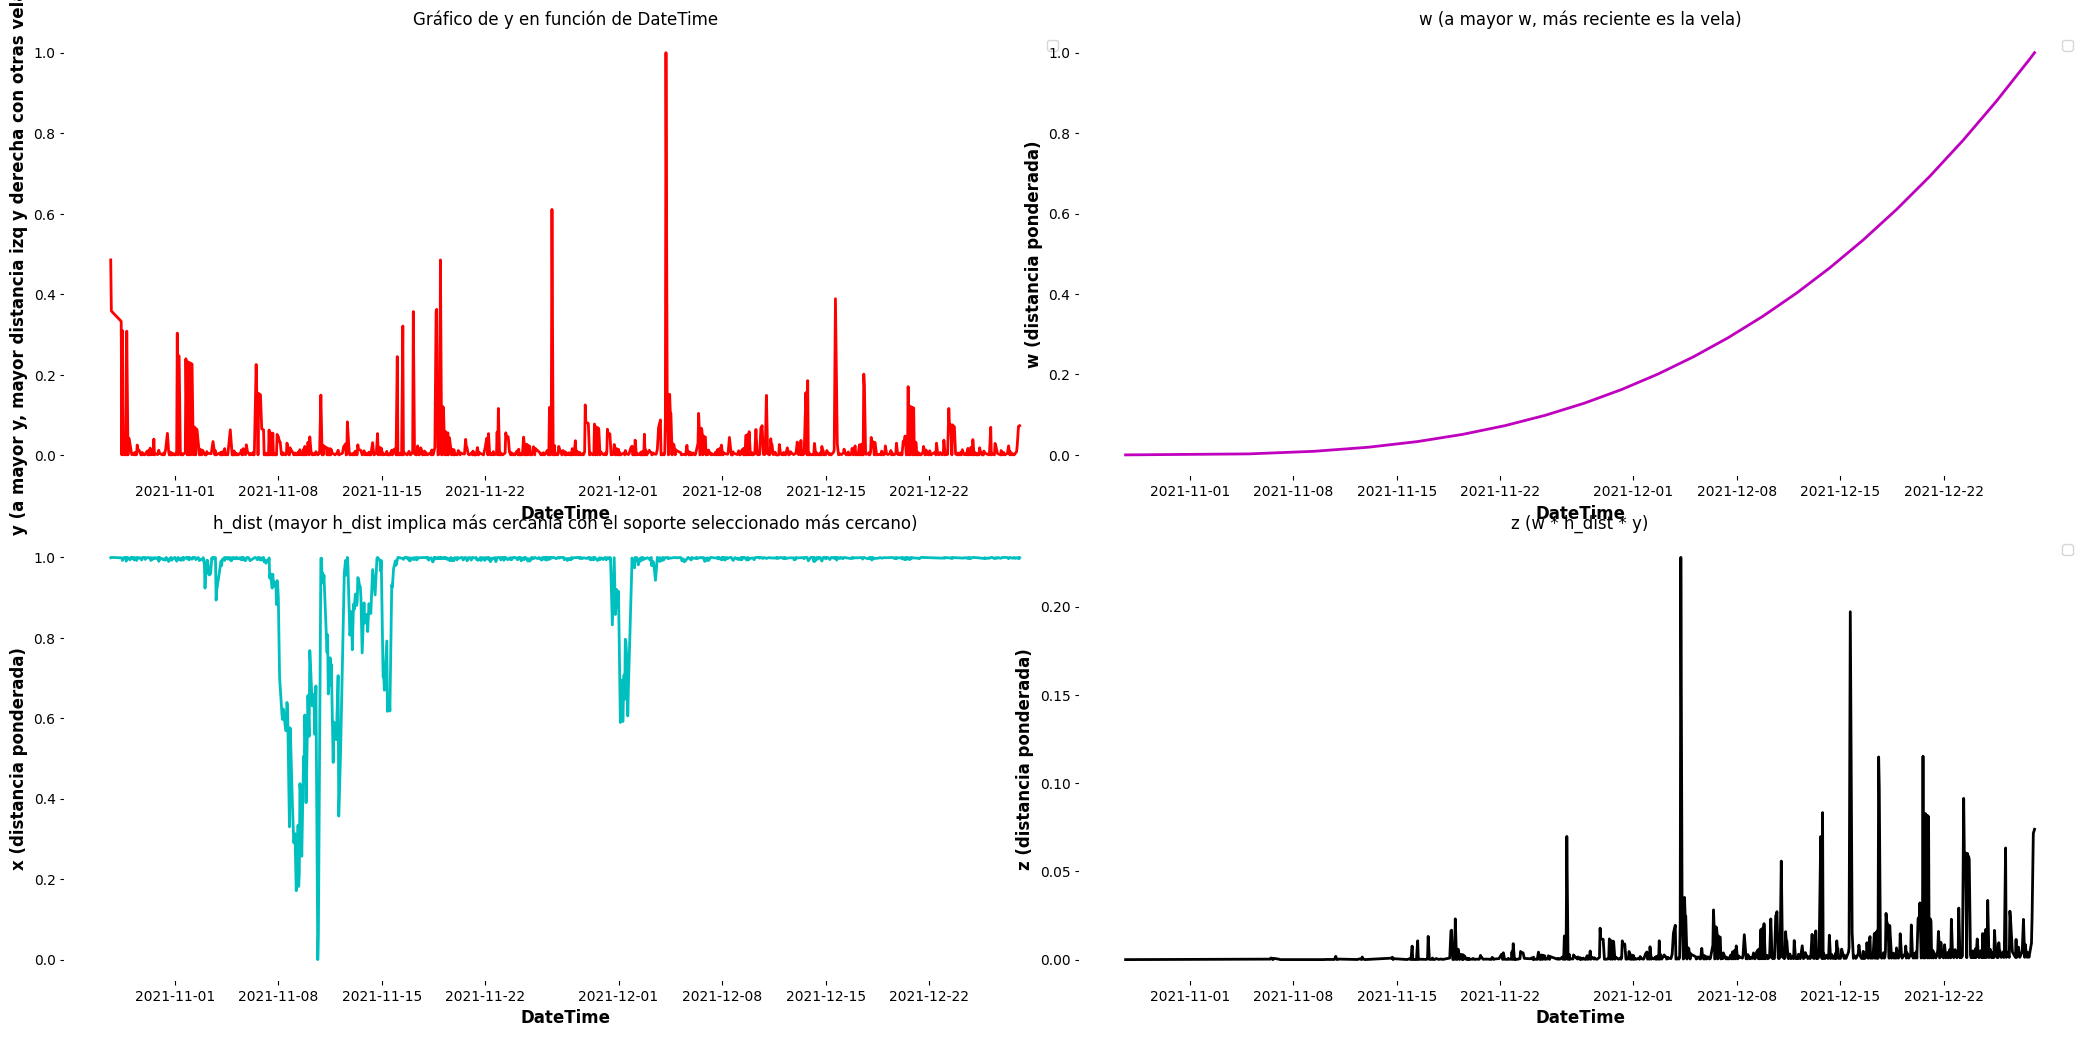

'df_extremos'

,DateTime,Open,High,Low,Close,Tick_Volume,Spread,Real_Volume,t,Low_left,Low_right,y,w,Soporte,dist,h_dist,z
0,2021-10-27 16:00:00,3975.23,3997.24,3949.80,3978.40,6258,39,0,0.000000,0.000000,0.485424,0.485424,0.000000e+00,3940.499565,86.498087,0.999164,0.000000e+00
1,2021-10-27 17:00:00,3978.40,4005.37,3976.33,3995.36,4345,39,0,0.000678,0.000678,0.357966,0.358644,3.116190e-10,3977.395306,1.134877,0.999989,1.117591e-10
2,2021-10-28 09:00:00,4118.85,4161.64,4109.15,4161.54,2528,268,0,0.011525,0.011525,0.321356,0.332881,1.530984e-06,4092.743043,269.188222,0.997397,5.083095e-07
3,2021-10-28 10:00:00,4162.30,4175.11,4138.99,4148.59,3998,268,0,0.012203,0.000678,0.000678,0.001356,1.817362e-06,4149.834348,117.599880,0.998863,2.461417e-09
4,2021-10-28 11:00:00,4148.42,4157.73,4120.62,4153.45,3895,247,0,0.012881,0.001356,0.308475,0.309831,2.137395e-06,4092.743043,777.124705,0.992485,6.572535e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2021-12-27 23:00:00,4062.25,4067.74,4032.42,4038.53,5740,374,0,0.997288,0.023729,0.000678,0.024407,9.918864e-01,4016.621304,249.598784,0.997586,2.415032e-02
1457,2021-12-28 00:00:00,4038.78,4039.02,4003.44,4030.57,6698,404,0,0.997966,0.069831,0.000678,0.070508,9.939107e-01,4016.621304,173.746784,0.998320,6.996138e-02
1458,2021-12-28 01:00:00,4030.55,4030.55,3969.41,3980.72,7525,408,0,0.998644,0.071186,0.000678,0.071864,9.959377e-01,3977.395306,63.765114,0.999383,7.152834e-02
1459,2021-12-28 02:00:00,3980.72,3995.60,3958.59,3967.67,6110,422,0,0.999322,0.071864,0.000678,0.072542,9.979675e-01,3940.499565,327.263831,0.996835,7.216582e-02


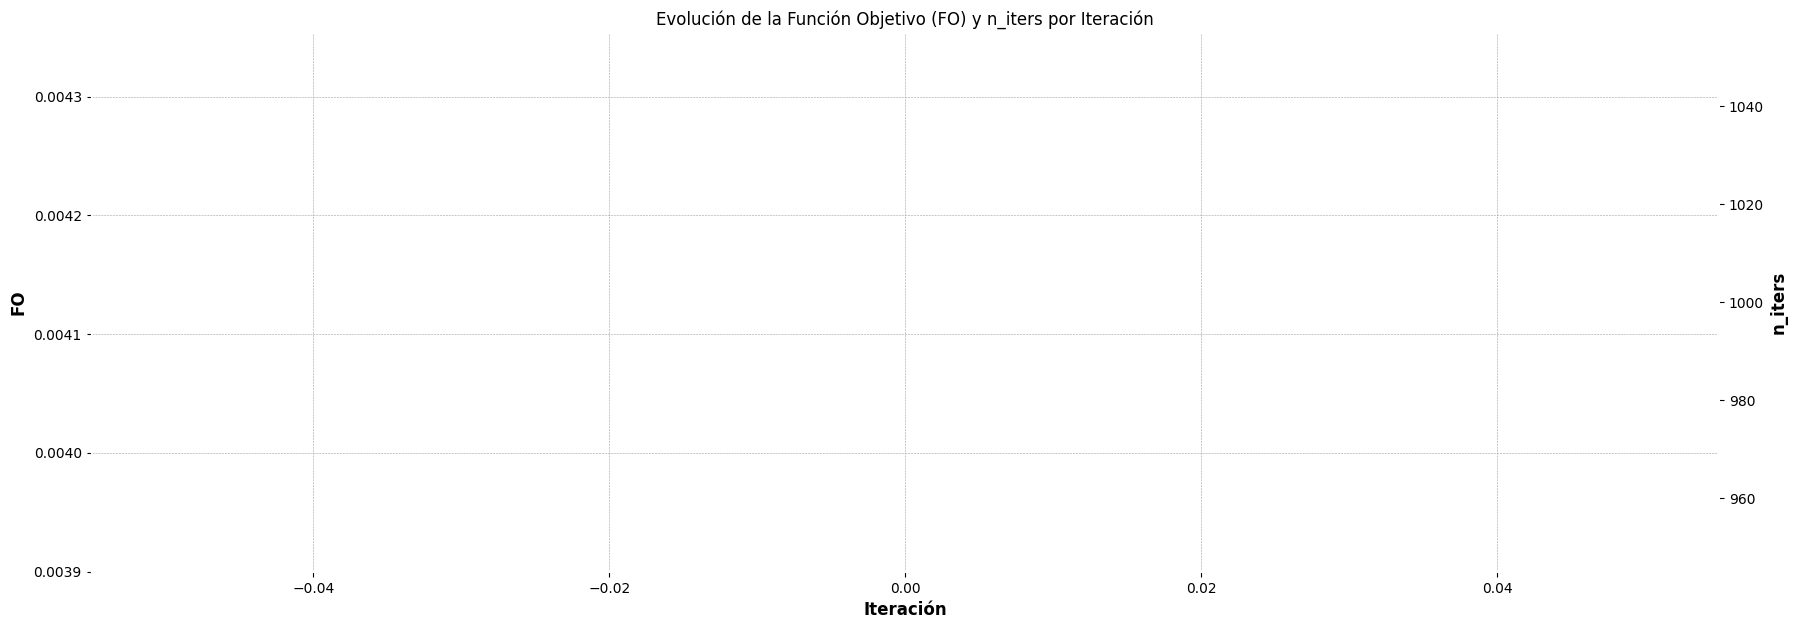

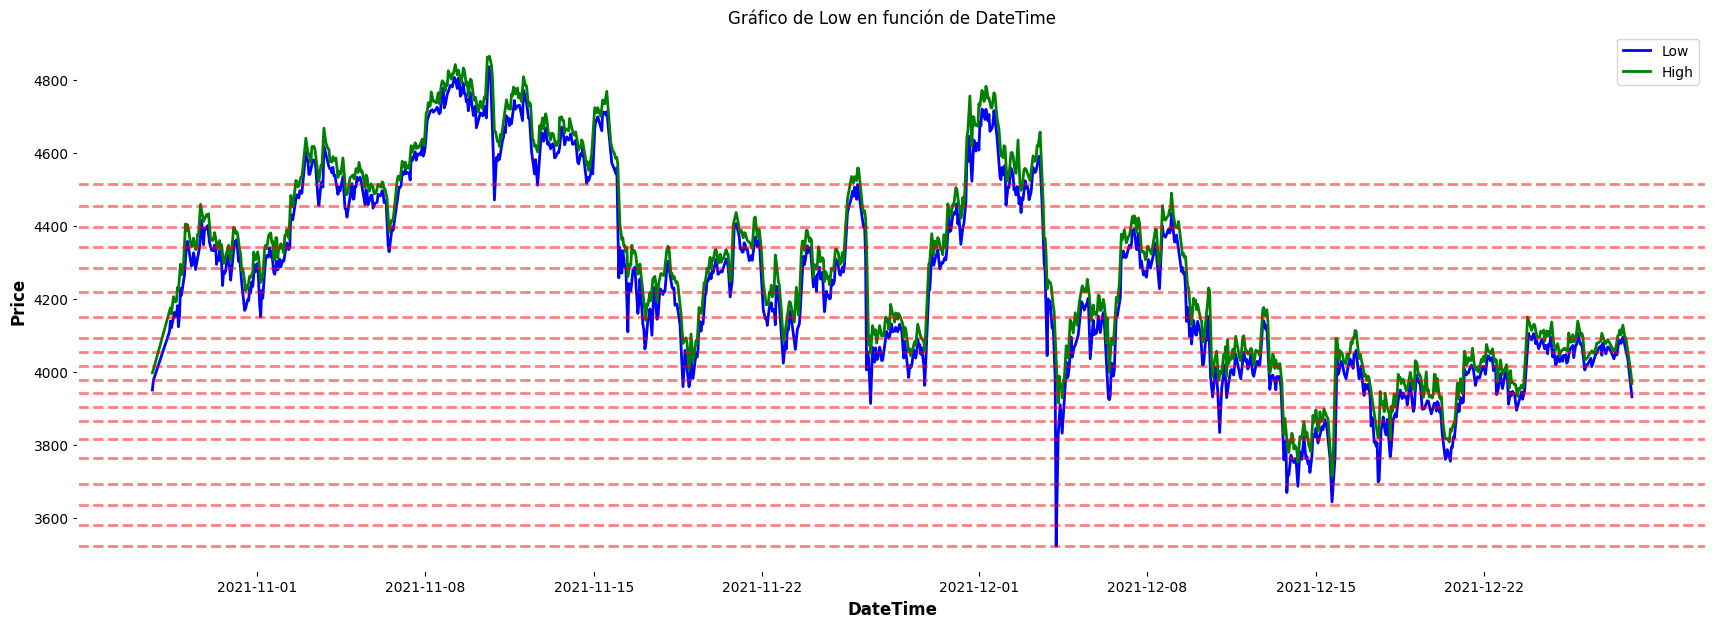

delta trigger y cambio SL 1 1
Actualización reemplazo de OC 36


'df_oc_all base inicial'

,periodo,ultimo_cierre,id,tipo_oc,n,beta,cambio_SL,trigger,SL_LP,Status,Monto Compra (lotes),Valor_actual
0,2021-12-26 15:00:00,4054.16,1,I,3521.830000,4.600940,NaN,3521.830000,3252.819702,Activa,NaN,0
1,2021-12-26 15:00:00,4054.16,2,I,3978.560435,4.388713,NaN,3978.560435,3649.406965,Abierta,0.4,0
2,2021-12-26 15:00:00,4054.16,3,I,3769.225652,4.485984,NaN,3769.225652,3500.215354,Inactiva,NaN,0
3,2021-12-26 15:00:00,4054.16,4,S,4054.682174,4.353342,4095.228996,4136.181286,3785.671876,Activa,NaN,0
4,2021-12-26 15:00:00,4054.16,5,I,3864.377826,4.441770,NaN,3864.377826,3595.367528,Activa,NaN,0
5,2021-12-26 15:00:00,4054.16,6,I,3940.499565,4.406399,NaN,3940.499565,3610.019675,Abierta,0.4,0
6,2021-12-26 15:00:00,4054.16,7,S,4454.321304,4.167643,4498.864517,4543.853163,4185.311006,Activa,NaN,0
7,2021-12-26 15:00:00,4054.16,8,S,4397.230000,4.194171,4441.202300,4485.614323,4128.219702,Activa,NaN,0
8,2021-12-26 15:00:00,4054.16,9,I,3693.103913,4.521355,NaN,3693.103913,3424.093615,Activa,NaN,0
9,2021-12-26 15:00:00,4054.16,10,S,4206.925652,4.282599,4248.994909,4291.484858,3937.915354,Inactiva,NaN,0


'df_rev'

,periodo,ultimo_cierre,id,tipo_oc,n,beta,cambio_SL,trigger,SL_LP,Status,Monto Compra (lotes),Valor_actual
10,2021-12-26 15:00:00,4054.16,11,I,4016.621304,4.371027,NaN,4016.621304,3688.794254,Activa,0.4,0
23,2021-12-28 00:00:00,4030.57,24,I,4016.621304,4.369452,NaN,4016.621304,3688.912399,Activa,0.4,0


SystemExit: No pueden haber activas con monto de compra notna

In [64]:
# 1. Leer el CSV
df = pd.read_csv(f'{carpeta_data}{valor}.csv')

# 2. Convertir la columna DateTime a datetime
df['DateTime'] = pd.to_datetime(df['DateTime'])

# 3. Establecer DateTime como índice
df_plot = df.set_index('DateTime')

if display_0:
    display('All gráfico', df)
    mpf.plot(df_plot, type = 'candle', volume = False, style = 'charles', figsize = (21, 7))

# Inicialización

dt_min = df['DateTime'].min()

dt_cut = dt_min + pd.Timedelta(days = T)
print(dt_min, dt_cut)

df_0 = df[(df['DateTime'] >= dt_min) & (df['DateTime'] < dt_cut)].copy() # df para comenzar las iteraciones
L_inicial = len(df_0)
print(len(df), len(df_0))
#sys.exit()

df_parametros = pd.DataFrame()
df_oc_all = pd.DataFrame()

for i_vela in range(len(df) + 1 - L_inicial):
    
    #print('i_vela', i_vela)
    
    if not activar:
        break
    
    # 0. Agregar una nueva vela al df y hacer lo siguiente
    df_0 = df.head(i_vela + L_inicial)
    
    ultimo_cierre = float(df_0['Close'].iloc[-1])
    ultimo_periodo = df_0['DateTime'].iloc[-1]

    # -1. df-parametros (una fila, con todos los parámetros actuales)
    df_parametros_new = pd.DataFrame({'ultimo_cierre': [ultimo_cierre],
                                    'ultimo_periodo': [ultimo_periodo],
                                  'T': [T],
                                  'k': [k],
                                  'n': [n],
                                  'M': [M],
                                  'N': [N],
                                  'lambda_ponderador': [lambda_ponderador],
                                  'delta_trigger': [delta_trigger],
                                  'delta_cambio_SL': [delta_cambio_SL],
                                  'beta_low': [beta_low],
                                  'beta_up': [beta_up],
                                  'z_sl_lp': [z_sl_lp],
                                  'cuenta_size': [cuenta_size]})
    df_parametros = pd.concat([df_parametros, df_parametros_new], ignore_index=True) # Guardar al final de la iteración
    
    df_plot_inicial = df_0.set_index('DateTime')
    if display_1:
        display(f'df0 [gráfico i_vela] {i_vela}', df_0)
        mpf.plot(df_plot_inicial, type = 'candle', volume = False, style = 'charles', figsize = (21, 7))

    dt_max = df['DateTime'].max()

    # Normalización de t, como referencia desde el inicio del periodo
    df_0['t'] = (df_0['DateTime'] - dt_min).dt.total_seconds() / 3600  # tiempo en horas desde el inicio
    df_0['t'] = df_0['t'] / df_0['t'].max()  # normalizar entre 0 y 1
    
    # 1: Recalcular soportes y REEMPLAZAR los que estaban (esto puede hacerse cada x velas, no en todas) [inicialmente, entra si o si i_vela == 0]
    if i_vela % paso == 0:
        
        print('TO DO: Si quedan pocos soportes activos (no ejecutados)....menor a un umbral....entrar aquí también')

        df_extremos, conjunto_N, conjunto_M = obtener_df_extremos(df_0, k, n, N, M)
        conjunto_N, conjunto_M, df_extremos, df_FO = buscar_soportes_optimos(df_extremos, conjunto_N, conjunto_M, lambda_ponderador)
        graficar_df_extremos(df_extremos, graficar = graficar_extremos)
        
        # H_n son las distancias entre los soportes en conjunto_N
        L_n = list(conjunto_N)
        L_n.sort()
        H_n = [L_n[i] - L_n[i-1] for i in range(1, len(L_n))]
        
        display('df_extremos', df_extremos)
        
        graficar_performance_FO(df_FO, graficar = graficar_perf_FO)
        graficar_soportes_all(df_0, conjunto_N, graficar = graficar_soportes)

        print('delta trigger y cambio SL', delta_trigger, delta_cambio_SL)
        
        # 1a. Crear ordenes de compra, bajo el precio inicial, en los soportes N (siempre)
        # 1b. Crear OC arriba del precio, siempre y cuando el precio máximo de la nueva vela, active el umbral
        mu, desv = float(df_extremos['Close'].mean()), float(df_extremos['Close'].std()) # mu y desv de los históricos hasta el momento [puede ser igual de los últimos k periodos]
        limite_low, limite_high = mu - 2 * desv, mu + 2 * desv
        limite_low, limite_high

        delta_SL_LP = z_sl_lp * desv  # Stop Loss a largo plazo (diferencia, bajo n [n - delta_SL_LP])
        print('Actualización periódica de OC')
        df_oc_all = generar_nuevas_oc(df_oc_all, conjunto_N, limite_low, limite_high, beta_low, beta_up, ultimo_cierre, delta_cambio_SL, delta_trigger, ultimo_periodo, delta_SL_LP)
        
    
    #display('df_oc_all', df_oc_all)
    #display('df_0', df_0.tail(15))
    
    # ANCLA 2
    # Prev (para activar)
    #if i_vela != 0: # No se activa nada en la primera iteración, por defecto
    df_oc_activas = df_oc_all[df_oc_all['Status'] == 'Activa'].copy().reset_index()
    df_oc_activas

    ultimo_min, ultimo_max = float(df_0['Low'].iloc[-1]), float(df_0['High'].iloc[-1])
    #print('ultimo_min, ultimo_max', ultimo_min, ultimo_max)

    # Si se gatilla un trigger
    existen_oc = False
    for n_orden in range(len(df_oc_activas)):
        trigger = float(df_oc_activas.loc[n_orden, 'trigger'])
        if ultimo_min <= trigger <= ultimo_max: # Se ejecuta una orden
            existen_oc = True
            periodo = df_oc_activas.loc[n_orden, 'periodo']
            print('Ejecución de orden', ultimo_min, trigger, ultimo_max)
            tipo_oc = df_oc_activas.loc[n_orden, 'tipo_oc']
            beta = float(df_oc_activas.loc[n_orden, 'beta'])
            cambio_SL = df_oc_activas.loc[n_orden, 'cambio_SL']
            sl_lp = float(df_oc_activas.loc[n_orden, 'SL_LP'])
            _id = int(df_oc_activas.loc[n_orden, 'id'])
            
            df_oc_all = ejecutar_orden_de_compra(df_oc_all, cuenta_size, beta, trigger, sl_lp, valor, _id) # Ejecución de orden de compra
            
            if tipo_oc == 'S':
                # 3: Generar cambios de SL, si se gatilla una OC arriba
                # Actualizar el SL de las órdenes abiertas, si corresponde
                print('i vela', i_vela, ' Actualización stop loss por orden ejecutada arriba')
                graficar_soportes_all(df_0, conjunto_N, graficar_zoom = True)
                df_oc_all = actualizar_stop_loss_ordenes_abiertas(df_oc_all, cambio_SL, valor)
                # c251114
                
            
            #display('df_oc_all 0', df_oc_all)
            #graficar_soportes_all(df_0, conjunto_N, graficar = graficar_soportes)
    
    # Para cada orden de compra, reemplazar N    
    if existen_oc:
        conjunto_N = set(df_oc_activas['n']) # n activos aún (base)
        
        # TO DO: Todo esto es bien igual a lo que está arriba, agrupar en una función
        df_extremos, conjunto_N, conjunto_M = obtener_df_extremos(df_0, k, n, N, M, existe_solucion = True, conjunto_N = conjunto_N)
        conjunto_N, conjunto_M, df_extremos, df_FO = buscar_soportes_optimos(df_extremos, conjunto_N, conjunto_M, lambda_ponderador, sizes = sizes)
        graficar_df_extremos(df_extremos, graficar = graficar_extremos)
        
        # H_n son las distancias entre los soportes en conjunto_N
        L_n = list(conjunto_N)
        L_n.sort()
        H_n = [L_n[i] - L_n[i-1] for i in range(1, len(L_n))]
        
        display('df_extremos', df_extremos)
        
        graficar_performance_FO(df_FO, graficar = graficar_perf_FO)
        graficar_soportes_all(df_0, conjunto_N, graficar = graficar_soportes)

        print('delta trigger y cambio SL', delta_trigger, delta_cambio_SL)
        
        # 1a. Crear ordenes de compra, bajo el precio inicial, en los soportes N (siempre)
        # 1b. Crear OC arriba del precio, siempre y cuando el precio máximo de la nueva vela, active el umbral
        mu, desv = float(df_extremos['Close'].mean()), float(df_extremos['Close'].std()) # mu y desv de los históricos hasta el momento [puede ser igual de los últimos k periodos]
        limite_low, limite_high = mu - 2 * desv, mu + 2 * desv
        limite_low, limite_high

        delta_SL_LP = z_sl_lp * desv  # Stop Loss a largo plazo (diferencia, bajo n [n - delta_SL_LP])
        print('Actualización reemplazo de OC', i_vela)
        df_oc_all = generar_nuevas_oc(df_oc_all, conjunto_N, limite_low, limite_high, beta_low, beta_up, ultimo_cierre, delta_cambio_SL, delta_trigger, ultimo_periodo, delta_SL_LP)
        
    if i_vela % 100 == 0:
        print('Continuar aquí 251028')
        print('Desarrollar actualizar valor de ordenes abiertas en df_oc_all y cuenta_size')
        # c251114
            #display('df_0', df_0)
            #display(mpf.plot(df_plot_inicial, type = 'candle', volume = False, style = 'charles', figsize = (21, 7)))
            #sys.exit('Continuar abajo en [ANCLA 2]')
        
    
    #sys.exit('Revisión para continuar abajo')
    # 2: Evaluar si se ejecuta una OC abajo (toque de soporte) y/o una OC arriba (alcanza el trigger [gatillante]) > Ejecutarla y guardarla en una BD
    #     Incluir en la BD el $ en cuenta, para calcular posteriormente pérdida o ganancia
    

    

In [ ]:
df_0

In [ ]:
df_oc_all

In [ ]:
# muestrame los triggers duplicados
df_oc_all[df_oc_all.duplicated(subset=['trigger'], keep=False)].sort_values(by='trigger')

# Algorítmo Preliminar (Inicial)

In [ ]:
sys.exit('Otros de aquí hhacia abajo')

In [ ]:
# 1. Leer el CSV
df = pd.read_csv(f'{carpeta_data}{valor}.csv')

# 2. Convertir la columna DateTime a datetime
df['DateTime'] = pd.to_datetime(df['DateTime'])

# 3. Establecer DateTime como índice
df_plot = df.set_index('DateTime')

display(df.head())

mpf.plot(df_plot, type = 'candle', volume = False, style = 'charles', figsize = (21, 7))



In [ ]:
# Parámetros

# T: Cantidad de días previos para selección de la ventana
T = 60 # 60 días
# k: ponderador para mínimos de los días futuros: P = delta pasado + k * delta futuro
k = 1
# n: exp de ponderación por tiempo: Ponderación por tiempo: w_i = exp(-n*(T-i)), i = 1,...,T / o puede ser w_i = A * t^n 
n = 0
# M: Cantidad de "soportes tentativos" fuera de los ocupados
M = 500
# N: Cantidad de "soportes" ocupados
N = 10
# lambda: ponderador para FO: Calidad resistencias - lambda * desv(h) / prom(h) ...h es la separación entre resistencias h_i = r_i - r_(i-1), para todo i = 2,...,N
lambda_ponderador = 1 / 60000
# delta trigger (en %), sobre el cambio SL
delta_trigger = 0.5
# delta cambio stop loss (en %)
delta_cambio_SL = 0.5

# Recordar que el orden, de arriba hacia abajo es delta trigger / delta cambio SL / soporte

In [ ]:
dt_min = df['DateTime'].min()
dt_min

dt_cut = dt_min + pd.Timedelta(days = T)
dt_cut

df_inicial = df[(df['DateTime'] >= dt_min) & (df['DateTime'] < dt_cut)].copy()
df_plot_inicial = df_inicial.set_index('DateTime')
mpf.plot(df_plot_inicial, type = 'candle', volume = False, style = 'charles', figsize = (21, 7))

dt_max = df['DateTime'].max()

# Normalización de t, como referencia desde el inicio del periodo
df_inicial['t'] = (df_inicial['DateTime'] - dt_min).dt.total_seconds() / 3600  # tiempo en horas desde el inicio
df_inicial['t'] = df_inicial['t'] / df_inicial['t'].max()  # normalizar entre 0 y 1
df_inicial


In [ ]:
import numpy as np
def calcular_distancias(df, find_low=True, find_high=True):
    n = len(df)
    df = df.copy()
    
    if find_low:
        df["Low_left"] = np.nan
        df["Low_right"] = np.nan
    if find_high:
        df["High_left"] = np.nan
        df["High_right"] = np.nan

    max_t = df["t"].max()

    for i in range(n):
        low_val = df.loc[i, "Low"]
        high_val = df.loc[i, "High"]
        t_i = df.loc[i, "t"]
        
        if find_low:
            # Buscar hacia la izquierda (Low)
            for j in range(i-1, -1, -1):
                if df.loc[j, "Low"] <= low_val <= df.loc[j, "High"]:
                    df.loc[i, "Low_left"] = t_i - df.loc[j, "t"]
                    break

            # Buscar hacia la derecha (Low)
            for j in range(i+1, n):
                if df.loc[j, "Low"] <= low_val <= df.loc[j, "High"]:
                    df.loc[i, "Low_right"] = df.loc[j, "t"] - t_i
                    break

        if find_high:
            # Buscar hacia la izquierda (High)
            for j in range(i-1, -1, -1):
                if df.loc[j, "Low"] <= high_val <= df.loc[j, "High"]:
                    df.loc[i, "High_left"] = t_i - df.loc[j, "t"]
                    break

            # Buscar hacia la derecha (High)
            for j in range(i+1, n):
                if df.loc[j, "Low"] <= high_val <= df.loc[j, "High"]:
                    df.loc[i, "High_right"] = df.loc[j, "t"] - t_i
                    break

    # Rellenar los NaN con t o max(t) - t
    if find_low:
        df["Low_left"] = df["Low_left"].fillna(df["t"])
        df["Low_right"] = df["Low_right"].fillna(max_t - df["t"])
    if find_high:
        df["High_left"] = df["High_left"].fillna(df["t"])
        df["High_right"] = df["High_right"].fillna(max_t - df["t"])

    return df

df_extremos = calcular_distancias(df_inicial, find_high=False)
df_extremos

In [ ]:
# Poonderadores (audios wsp personal 251002)
df_extremos['y'] = df_extremos['Low_left'] + k * df_extremos['Low_right']
df_extremos['w'] = df_extremos['t'] ** n

In [ ]:
df_extremos

# Grafica en una matriz de 2x1, Low e y
plt.figure(figsize=(21, 10))
plt.subplot(2, 1, 1)
plt.plot(df_extremos['DateTime'], df_extremos['Low'], linestyle='-', color='b', label='Low')
plt.plot(df_extremos['DateTime'], df_extremos['High'], linestyle='-', color='g', label='High')
plt.xlabel('DateTime')
plt.ylabel('Low')
plt.title('Gráfico de Low en función de DateTime')
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(df_extremos['DateTime'], df_extremos['y'], linestyle='-', color='r', label='y (distancia ponderada)')
plt.xlabel('DateTime')
plt.ylabel('y (distancia ponderada)')
plt.title('Gráfico de y en función de DateTime')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


Búsqueda de Soportes

In [ ]:
N, M

In [ ]:
df_extremos

p_min, p_max = df_extremos['Low'].min(), df_extremos['Low'].max()
p_min, p_max

In [ ]:
existe_solucion = False
if existe_solucion:
    sys.exit('Desarrollar')

# Si no existe solución, generar todas las posibles
all_soluciones_posibles = np.linspace(p_min, p_max, M + N).tolist()
print(len(all_soluciones_posibles))

# Elegir N random de este conjunto (deben ser distintas)

conjunto_N = set(random.sample(all_soluciones_posibles, N))
conjunto_M = set(all_soluciones_posibles) - conjunto_N
len(conjunto_N), len(conjunto_M)


In [ ]:
# Al Low en df extremos, asignarle el soporte más cercano en conjunto_N
def asignar_soporte(df, soportes):
    df = df.copy()
    df['Soporte'] = df['Low'].apply(lambda x: min(soportes, key=lambda s: abs(s - x)))
    return df

def calcular_FO(df_extremos, conjunto_N, lambda_ponderador):

    biobjetivo = True
    
    df_extremos = asignar_soporte(df_extremos, conjunto_N)
    df_extremos['dist'] = abs(df_extremos['Low'] - df_extremos['Soporte']) ** 2
    dist_max = df_extremos['dist'].max()
    df_extremos['h_dist'] = 1 - df_extremos['dist'] / dist_max
    df_extremos
    
    # Calcular la función objetivo

    df_extremos['z'] = df_extremos['y'] * df_extremos['w'] * df_extremos['h_dist']
    # z debe ser grande
    # y: mejor representación de soporte
    # w: mas cercano
    # h_dist: mejor ajuste al soporte del conjunto n

    L_n = list(conjunto_N)
    L_n.sort()
    H_n = [L_n[i] - L_n[i-1] for i in range(1, len(L_n))]

    # calcula promedio de conjunto_N
    promedio_conjunto_H = np.mean(H_n)
    # desviación estándar de conjunto_N
    desviacion_conjunto_H = np.std(H_n)

    # cv del conjunto n
    cv_conjunto_H = desviacion_conjunto_H / promedio_conjunto_H

    # cv_conjunto_N debe ser pequeño
    
    if biobjetivo:
        #print("df_extremos['z'].sum() / len(df_extremos)", df_extremos['z'].sum() / len(df_extremos), df_extremos['z'].sum(), len(df_extremos))
        #print('cv_conjunto_H', cv_conjunto_H, desviacion_conjunto_H, promedio_conjunto_H)
        # FO = sum(z) - lambda * cv_conjunto_N
        #sys.exit('También normalizar cv conjunto H y definir un nuevo lambda_ponderador inicial')
        FO = df_extremos['z'].sum() / len(df_extremos) - lambda_ponderador * cv_conjunto_H # Se divide por len para normalizar
    else:
        FO = (df_extremos['z'].sum() / len(df_extremos)) / cv_conjunto_H
        
    FO = float(FO)
    return FO, df_extremos

In [ ]:
"""
df_extremos['h_dist'].min(), df_extremos['h_dist'].max()

# Grafica un hist de h_dist
plt.figure(figsize=(10, 6))
plt.hist(df_extremos['h_dist'], bins=30, color='salmon', alpha=0.5)
plt.xlabel('h_dist')
plt.ylabel('Frecuencia')
plt.title('Histograma de h_dist')
plt.grid()
plt.show()
"""

In [ ]:
len(conjunto_N) * len(conjunto_M)

In [ ]:
# Uno a uno, reemplaza un punto del conjunto N por uno del conjunto M

print('L(N) * L(M)', len(conjunto_N) * len(conjunto_M))
df_FO = pd.DataFrame(columns = ['Iteracion', 'FO'])

# inicialización
FO, df_extremos = calcular_FO(df_extremos, conjunto_N, lambda_ponderador)
i = 0
while True:
    cambios = False
    #print('i', i)
    j = 0
    for n, m in tqdm.tqdm(itertools.product(conjunto_N, conjunto_M)):
        j += 1
        #print(n, m)
        
        conjunto_N_iter = conjunto_N.copy()
        conjunto_N_iter.remove(n)
        conjunto_N_iter.add(m)
        
        conjunto_M_iter = conjunto_M.copy()
        conjunto_M_iter.remove(m)
        conjunto_M_iter.add(n)

        FO_iter, df_extremos_iter = calcular_FO(df_extremos, conjunto_N_iter, lambda_ponderador)
        
        if FO_iter > FO:
            #print(f'Nueva FO: {round(FO_iter, 1)} > {round(FO, 1)}, con n={round(n, 0)} por m={round(m, 0)}')
            #print(f'Mejora de {round(FO_iter - FO, 2)}')
            FO = FO_iter
            df_extremos = df_extremos_iter
            conjunto_N = conjunto_N_iter
            conjunto_M = conjunto_M_iter
            cambios = True
            break
            
    df_FO_new = pd.DataFrame({'Iteracion': [i], 'FO': [FO], 'n_iters': [j]})
    df_FO = pd.concat([df_FO, df_FO_new], ignore_index=True)
    i += 1
    if not cambios:
        break


In [ ]:
conjunto_N

L_n = list(conjunto_N)
L_n.sort()
H_n = [L_n[i] - L_n[i-1] for i in range(1, len(L_n))]
H_n

In [ ]:
df_extremos

In [ ]:
# Graficar df_FO a doble eje (FO y n_iters vs iteracion)

plt.figure(figsize = (21, 7))
plt.plot(df_FO['Iteracion'], df_FO['FO'], linestyle='-', color='b', label='FO')
plt.ylabel('FO')
plt.xlabel('Iteración')
plt.twinx()
plt.plot(df_FO['Iteracion'], df_FO['n_iters'], linestyle='-', color='r', label='n_iters')
plt.ylabel('n_iters')
plt.title('Evolución de la Función Objetivo (FO) y n_iters por Iteración')
plt.grid()
plt.show()


In [ ]:
plt.figure(figsize = (21, 7))
plt.plot(df_extremos['DateTime'], df_extremos['Low'], linestyle='-', color='b', label='Low')
plt.plot(df_extremos['DateTime'], df_extremos['High'], linestyle='-', color='g', label='High')
for n in list(conjunto_N):
    plt.axhline(y = n, color = 'r', linestyle = '--', alpha = 0.5)
plt.xlabel('DateTime')
plt.ylabel('Low')
plt.title('Gráfico de Low en función de DateTime')
plt.grid() # Agrega una cuadrícula
plt.legend()
plt.show()

In [ ]:
# Que viene después?

# 1. Crear ordenes de compra, bajo el precio inicial, en los soportes N
# 1A. Crear OC arriba del precio, siempe y cuando el precio máximo de la nueva vela, active el umbral
# B. Agregar una nueva vela al df y hacer lo siguiente
# B1: Evaluar si se ejecuta una OC abajo (toque de soporte) y/o una OC arriba (alcanza el trigger [gatillante]) > Ejecutarla y guardarla en una BD
#     Incluir en la BD el $ en cuenta, para calcular posteriormente pérdida o ganancia
# B2: Generar cambios de SL, si se gatilla una OC arriba
# B3: Evaluar si hay cierres de operación y cerrar en caso de que existan
# B4: Recalcular soportes y REEMPLAZAR los que estaban (esto puede hacerse cada x velas, no en todas) 
# B5: Con RLM, y gradient descent (70% train - 30% test), optimizar los parámetros declarados arriba

# ** En todos los casos, ir guardando los registros
delta_trigger, delta_cambio_SL

In [ ]:
sys.exit('Continuar aquí 251007')

# Otros

In [ ]:
import yfinance as yf
print(yf.__version__)

# Definir ticker y periodo
ticker = 'USDCLP=X'  # ejemplo Apple
#ticker = 'AAPL'  # ejemplo Apple
print(ticker)
data = yf.download(ticker)  # intervalo de 60 minutos
data


In [ ]:

from datetime import datetime, timedelta
import yfinance as yf

end_date = datetime.today()
start_date = end_date - timedelta(days=30)

data = yf.download('USDCLP=X', start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), interval='1d')
print(data.head())


In [ ]:

import yfinance as yf
from datetime import datetime, timedelta

ticker = yf.Ticker("USDCLP=X")
end_date = datetime.today()
start_date = end_date - timedelta(days=10)

data = ticker.history(start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), interval='1d')



# Original chat gpt

https://chatgpt.com/share/686720eb-f8f4-8009-a56b-5d97bced1a2e

In [ ]:
# ----------------------------------------
# 1. Instalar librerías (si no las tienes)
# ----------------------------------------
# pip install yfinance pandas matplotlib

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------
# 2. Descargar datos históricos
# ----------------------------------------
# Por ejemplo, de Apple
ticker = "AAPL"
df = yf.download(ticker, start="2018-01-01", end="2023-01-01")
df = df[['Close']].copy()

# ----------------------------------------
# 3. Calcular medias móviles
# ----------------------------------------
df['SMA50'] = df['Close'].rolling(window=50).mean()
df['SMA200'] = df['Close'].rolling(window=200).mean()

# ----------------------------------------
# 4. Generar señales de compra/venta
# ----------------------------------------
df['Signal'] = 0
df.loc[df['SMA50'] > df['SMA200'], 'Signal'] = 1
df.loc[df['SMA50'] <= df['SMA200'], 'Signal'] = 0
df['Position'] = df['Signal'].diff()

# ----------------------------------------
# 5. Graficar
# ----------------------------------------
plt.figure(figsize=(14,7))
plt.plot(df['Close'], label='Precio de Cierre', alpha=0.5)
plt.plot(df['SMA50'], label='SMA 50', alpha=0.9)
plt.plot(df['SMA200'], label='SMA 200', alpha=0.9)
plt.plot(df[df['Position'] == 1].index, 
         df['SMA50'][df['Position'] == 1],
         '^', markersize=12, color='g', label='Buy Signal')
plt.plot(df[df['Position'] == -1].index, 
         df['SMA50'][df['Position'] == -1],
         'v', markersize=12, color='r', label='Sell Signal')
plt.title(f"{ticker} - Estrategia Cruce de Medias Móviles")
plt.legend()
plt.show()

# ----------------------------------------
# 6. Backtest muy básico
# ----------------------------------------
# Retornos diarios
df['Return'] = df['Close'].pct_change()

# Retornos de estrategia
df['Strategy'] = df['Signal'].shift(1) * df['Return']

df[['Return', 'Strategy']].dropna().cumsum().apply(np.exp).plot(figsize=(12,6))
plt.title(f"{ticker} - Buy & Hold vs Estrategia")
plt.show()


In [ ]:
sys.exit()

# Otras pruebas

In [ ]:
# ----------------------------------------
# 1. Instalar librerías (si no las tienes)
# ----------------------------------------
# pip install yfinance pandas matplotlib

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------
# 2. Descargar datos históricos
# ----------------------------------------
# Por ejemplo, de Apple
ticker = "MSFT"
df = yf.download(ticker, start="2020-01-01")
df = df[['Close']].copy()

# ----------------------------------------
# 3. Calcular medias móviles
# ----------------------------------------
df['SMA50'] = df['Close'].rolling(window=10).mean()
df['SMA200'] = df['Close'].rolling(window=40).mean()

# ----------------------------------------
# 4. Generar señales de compra/venta
# ----------------------------------------
df['Signal'] = 0
df.loc[df['SMA50'] > df['SMA200'], 'Signal'] = 1
df.loc[df['SMA50'] <= df['SMA200'], 'Signal'] = 0
df['Position'] = df['Signal'].diff()

# ----------------------------------------
# 5. Graficar
# ----------------------------------------
plt.figure(figsize=(14,7))
plt.plot(df['Close'], label='Precio de Cierre', alpha=0.5)
plt.plot(df['SMA50'], label='SMA 50', alpha=0.9)
plt.plot(df['SMA200'], label='SMA 200', alpha=0.9)
plt.plot(df[df['Position'] == 1].index, 
         df['SMA50'][df['Position'] == 1],
         '^', markersize=12, color='g', label='Buy Signal')
plt.plot(df[df['Position'] == -1].index, 
         df['SMA50'][df['Position'] == -1],
         'v', markersize=12, color='r', label='Sell Signal')
plt.title(f"{ticker} - Estrategia Cruce de Medias Móviles")
plt.legend()
plt.show()

# Encuentra el primer día donde la estrategia toma posición (Signal == 1)
start_idx = df[df['Signal'] == 1].first_valid_index()

# Corta el DataFrame desde ese momento
df_bt = df.loc[start_idx:].copy()

# Calcula retornos de ambas estrategias desde el mismo punto
df_bt['Return'] = df_bt['Close'].pct_change()
df_bt['Strategy'] = df_bt['Signal'].shift(1) * df_bt['Return']

# Capital acumulado
df_bt['Equity_BuyHold'] = (1 + df_bt['Return']).cumprod()
df_bt['Equity_Strategy'] = (1 + df_bt['Strategy']).cumprod()

# Graficar
df_bt[['Equity_BuyHold', 'Equity_Strategy']].plot(figsize=(12,6))
plt.title(f"{ticker} - Buy & Hold vs Estrategia (Sincronizados)")
plt.show()


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# ------------------------------
# 1. Descargar datos
# ------------------------------
ticker = "MSFT"
start_date = "2018-01-01"
df = yf.download(ticker, start=start_date)
df = df[['Close']].copy()

# ------------------------------
# 2. Definir rangos para las medias móviles
# ------------------------------
#cortas = range(5, 30, 5)
#medias = range(30, 90, 10)
#largas = range(90, 210, 10)

cortas = range(5, 30, 15)
medias = range(30, 90, 30)
largas = range(90, 210, 30)


#
# Función estrategia
def run_strategy(df_base, s_corta, s_media, s_larga):
    df = df_base.copy()

    # Asegurar que 'Return' exista (calcular si no está)
    if 'Return' not in df.columns:
        df['Return'] = df['Close'].pct_change()

    df['SMA_c'] = df['Close'].rolling(window=s_corta).mean()
    df['SMA_m'] = df['Close'].rolling(window=s_media).mean()
    df['SMA_l'] = df['Close'].rolling(window=s_larga).mean()

    def classify(row):
        try:
            s1, s2, s3 = float(row['SMA_c']), float(row['SMA_m']), float(row['SMA_l'])
        except:
            return np.nan
        smas = [('c', s1), ('m', s2), ('l', s3)]
        ranking = ''.join([k for k, _ in sorted(smas, key=lambda x: -x[1])])
        if ranking == 'cml':
            return 1
        elif ranking == 'mcl':
            return 0.5
        elif ranking in ['mlc', 'clm']:
            return 0.25
        elif ranking in ['lmc', 'lcm']:
            return 0
        return 0

    df['Signal'] = df.apply(classify, axis=1)
    df.dropna(inplace=True)
    df['Position'] = df['Signal'].shift(1)
    df['Strategy'] = df['Position'] * df['Return']

    first_entry_idx = df.index[(df['Position'] > 0)].min()
    if pd.isna(first_entry_idx):
        # Nunca entra, retorno 1 (sin ganancias)
        return 1.0, 1.0, df

    df_sub = df.loc[first_entry_idx:].copy()
    df_sub['Equity_Strategy'] = (1 + df_sub['Strategy']).cumprod()
    df_sub['Equity_BuyHold'] = (1 + df_sub['Return']).cumprod()

    return df_sub['Equity_Strategy'].iloc[-1], df_sub['Equity_BuyHold'].iloc[-1], df_sub


# Ejecutar grid
results = []
combos = [ (s_c, s_m, s_l) for s_c, s_m, s_l in product(cortas, medias, largas) if s_c < s_m < s_l ]

for s_c, s_m, s_l in tqdm(combos, desc="Probando combinaciones"):
    try:
        strat_final, bh_final, _ = run_strategy(df, s_c, s_m, s_l)
        
        # Debug print para verificar valores
        print(f"Combo ({s_c},{s_m},{s_l}) -> strat_final: {strat_final}, bh_final: {bh_final}")
        
        # Validar que sean floats y no nan
        if (isinstance(strat_final, float) and isinstance(bh_final, float) 
            and not np.isnan(strat_final) and not np.isnan(bh_final)):
            results.append({
                'Corta': s_c, 'Media': s_m, 'Larga': s_l, 
                'EquityStrategy': strat_final, 'EquityBuyHold': bh_final
            })
        else:
            print(f"Valores inválidos para combo ({s_c},{s_m},{s_l}), se omite.")
            
    except Exception as e:
        print(f"Error combo ({s_c},{s_m},{s_l}): {e}")

results_df = pd.DataFrame(results)

print("Columnas del DataFrame:", results_df.columns)
print("Primeras filas del DataFrame:")
print(results_df.head())

# Ordenar solo si la columna existe
if 'EquityStrategy' in results_df.columns:
    results_df.sort_values('EquityStrategy', ascending=False, inplace=True)
else:
    print("No se encontró la columna 'EquityStrategy' en results_df. No se ordenará.")


# Ver columnas y primeras filas (debug)
print(results_df.columns)
print(results_df.head())

# Ordenar por EquityStrategy
results_df.sort_values('EquityStrategy', ascending=False, inplace=True)

print("Top 10 mejores combinaciones:")
print(results_df.head(10))

# Graficar las 10 mejores combinaciones
plt.figure(figsize=(16, 12))

top_10 = results_df.head(10).reset_index(drop=True)

for i, row in top_10.iterrows():
    s_c, s_m, s_l = int(row['Corta']), int(row['Media']), int(row['Larga'])
    print(f"Graficando combinación: Corta={s_c} Media={s_m} Larga={s_l}")
    _, _, df_plot = run_strategy(df, s_c, s_m, s_l)

    plt.subplot(5, 2, i+1)
    plt.plot(df_plot.index, df_plot['Equity_BuyHold'], label='Buy & Hold', linestyle='--')
    plt.plot(df_plot.index, df_plot['Equity_Strategy'], label=f'SMA({s_c},{s_m},{s_l})')
    plt.title(f"{ticker} - SMA({s_c}, {s_m}, {s_l})\nEquity Estrategia: {results_df.loc[i,'EquityStrategy']:.2f}")
    plt.ylabel('Multiplicador capital')
    plt.xlabel('Fecha')
    plt.legend(fontsize=8)
    plt.grid(True)


plt.tight_layout()
plt.show()

# Fundamentales

In [ ]:
import yfinance as yf
ticker = yf.Ticker("MSFT")
info = ticker.info


In [ ]:
info

In [ ]:
import yfinance as yf
import pandas as pd

# Lista de símbolos (puedes agregar los que quieras)
symbols = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]

# Campos fundamentales que queremos extraer
fundamental_fields = {
    "shortName": "Nombre",
    "sector": "Sector",
    "marketCap": "MarketCap",
    "trailingPE": "PE",
    "forwardPE": "ForwardPE",
    "returnOnEquity": "ROE",
    "profitMargins": "MargenNeto",
    "dividendYield": "DivYield",
    "beta": "Beta"
}

# Crear lista para resultados
data = []

for symbol in symbols:
    try:
        ticker = yf.Ticker(symbol)
        info = ticker.info

        row = {"Ticker": symbol}
        for key, label in fundamental_fields.items():
            row[label] = info.get(key, None)

        data.append(row)

    except Exception as e:
        print(f"Error con {symbol}: {e}")

# Crear DataFrame
df_fundamentales = pd.DataFrame(data)

# Mostrar
display(df_fundamentales)

# Evitar división por cero o NaN en PE o DivYield:
df_fundamentales['PE'].replace(0, np.nan, inplace=True)
df_fundamentales['DivYield'].fillna(0, inplace=True)

# Normalizamos cada indicador para que estén en rango similar (0 a 1)
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

df_fundamentales['score_ROE'] = normalize(df_fundamentales['ROE'])
df_fundamentales['score_PE'] = 1 - normalize(df_fundamentales['PE'])  # Inverso porque PE bajo es bueno
df_fundamentales['score_DivYield'] = normalize(df_fundamentales['DivYield'])

# Score total simple (promedio)
df_fundamentales['Score_Total'] = df_fundamentales[['score_ROE', 'score_PE', 'score_DivYield']].mean(axis=1)

# Ordenar por score descendente
df_sorted = df_fundamentales.sort_values('Score_Total', ascending=False)

# Mostrar top 5
display(df_sorted[['Ticker', 'Nombre', 'Score_Total', 'ROE', 'PE', 'DivYield']].head(5))

In [ ]:
import pandas as pd
import yfinance as yf
from IPython.display import display

# Obtener la tabla con los componentes del S&P 500 desde Wikipedia
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
tables = pd.read_html(url)
df_sp500 = tables[0]
df_sp500

In [ ]:
import pandas as pd
import yfinance as yf
from IPython.display import display

# Obtener la tabla con los componentes del S&P 500 desde Wikipedia
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
tables = pd.read_html(url)
df_sp500 = tables[0]

# Extraer símbolos (Tickers)
tickers = df_sp500['Symbol'].tolist()[:50]

print(f"Número de empresas obtenidas: {len(tickers)}")

# Por ejemplo, tomar las primeras 100 para no saturar la consulta
tickers = tickers[:10]

# Función para obtener fundamentales (como antes)
def get_fundamentals(sym):
    try:
        ticker = yf.Ticker(sym)
        info = ticker.info
        data = {
            'Ticker': sym,
            'Nombre': info.get('shortName', None),
            'Sector': info.get('sector', None),
            'MarketCap': info.get('marketCap', None),
            'PE': info.get('trailingPE', None),
            'ForwardPE': info.get('forwardPE', None),
            'ROE': info.get('returnOnEquity', None),
            'NetMargin': info.get('profitMargins', None),
            'DivYield': info.get('dividendYield', None),
            'Beta': info.get('beta', None),
            'Price': info.get('currentPrice', None)
        }
        return data
    except Exception as e:
        print(f"Error con {sym}: {e}")
        return None

# Obtener fundamentales para las 100 empresas (puede tardar un poco)
fundamentals = []
for sym in tickers:
    f = get_fundamentals(sym)
    if f:
        fundamentals.append(f)

df = pd.DataFrame(fundamentals)
display(df.head(20))


# Ejemplo sencillo de score:
# Sumamos puntajes (por ejemplo: ROE positivo suma, PE bajo suma, D/E bajo suma, etc.)
def score_row(r):
    score = 0
    if pd.notna(r['ROE']):
        score += (2 * r['ROE'])
    if pd.notna(r['PE']) and r['PE'] < 25:
        score += 1
    if pd.notna(r['NetMargin']):
        score += (0.5 * r['NetMargin'])
    if pd.notna(r['DivYield']) and r['DivYield'] > 0.01:
        score += 0.5
    return score


df['Score'] = df.apply(score_row, axis=1)

# Ordenar por Score descendente
df = df.sort_values('Score', ascending=False)

print("\nTop activos según score fundamental:")
display(df[['Ticker', 'Nombre', 'Score']])


In [ ]:
ticker = yf.Ticker('BTC-USD')
info = ticker.info
info

In [ ]:
print(df.columns)

In [ ]:
sys.exit()

In [ ]:
# ----------------------------------------
# 1. Instalar librerías (si no las tienes)
# ----------------------------------------
# pip install yfinance pandas matplotlib

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------
# 2. Descargar datos históricos
# ----------------------------------------
# Por ejemplo, de Apple
ticker = "TSLA"
df = yf.download(ticker)
df = df[['Close']].copy()

# ----------------------------------------
# 3. Calcular medias móviles
# ----------------------------------------
df['SMA50'] = df['Close'].rolling(window=20).mean()
df['SMA200'] = df['Close'].rolling(window=50).mean()

# ----------------------------------------
# 4. Generar señales de compra/venta
# ----------------------------------------
df['Signal'] = 0
df.loc[df['SMA50'] > df['SMA200'], 'Signal'] = 1
df.loc[df['SMA50'] <= df['SMA200'], 'Signal'] = 0
df['Position'] = df['Signal'].diff()

# ----------------------------------------
# 5. Graficar
# ----------------------------------------
plt.figure(figsize=(14,7))
plt.plot(df['Close'], label='Precio de Cierre', alpha=0.5)
plt.plot(df['SMA50'], label='SMA 50', alpha=0.9)
plt.plot(df['SMA200'], label='SMA 200', alpha=0.9)
plt.plot(df[df['Position'] == 1].index, 
         df['SMA50'][df['Position'] == 1],
         '^', markersize=12, color='g', label='Buy Signal')
plt.plot(df[df['Position'] == -1].index, 
         df['SMA50'][df['Position'] == -1],
         'v', markersize=12, color='r', label='Sell Signal')
plt.title(f"{ticker} - Estrategia Cruce de Medias Móviles")
plt.legend()
plt.show()

# ----------------------------------------
# 6. Backtest muy básico
# ----------------------------------------
# Retornos diarios
df['Return'] = df['Close'].pct_change()

# Retornos de estrategia
df['Strategy'] = df['Signal'].shift(1) * df['Return']

df[['Return', 'Strategy']].dropna().cumsum().apply(np.exp).plot(figsize=(12,6))
plt.title(f"{ticker} - Buy & Hold vs Estrategia")
plt.show()


In [ ]:
import backtrader as bt
from datetime import datetime


class SmaCross(bt.Strategy):
    # Estrategia de cruce de medias móviles
    def __init__(self):
        sma1 = bt.indicators.SimpleMovingAverage(self.data.close, period=50)
        sma2 = bt.indicators.SimpleMovingAverage(self.data.close, period=200)
        self.crossover = bt.indicators.CrossOver(sma1, sma2)

    def next(self):
        if not self.position:
            if self.crossover > 0:
                self.buy()
        elif self.crossover < 0:
            self.sell()

cerebro = bt.Cerebro()
data = bt.feeds.YahooFinanceData(dataname='AAPL',
                                 fromdate=datetime(2018, 1, 1),
                                 todate=datetime(2023, 1, 1))
cerebro.adddata(data)
cerebro.addstrategy(SmaCross)
cerebro.run()
cerebro.plot()
